In [122]:
%%capture
!pip install ucimlrepo
!pip install mlflow

In [123]:
%%capture
import warnings
from ucimlrepo import fetch_ucirepo
from typing import Tuple, Callable, Union
from sklearn.base import BaseEstimator
from sklearn.model_selection import BaseCrossValidator
warnings.filterwarnings("ignore")
%matplotlib inline
import os
import missingno as msno
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
import mlflow.pyfunc
from sklearn.model_selection import train_test_split,StratifiedKFold, GridSearchCV
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder, MinMaxScaler, StandardScaler, FunctionTransformer, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, roc_auc_score, roc_curve,auc, confusion_matrix, make_scorer
from imblearn.over_sampling import SMOTE
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option('display.max_colwidth', None)
plt.style.use("ggplot")
sns.set_palette(sns.diverging_palette(220, 20))

In [124]:
from ucimlrepo import fetch_ucirepo
heart_disease = fetch_ucirepo(id=45)

features = heart_disease.data.features
targets = heart_disease.data.targets

df = pd.concat(
    [features,
     targets],
    axis=1
)
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
5,56,1,2,120,236,0,0,178,0,0.8,1,0.0,3.0,0
6,62,0,4,140,268,0,2,160,0,3.6,3,2.0,3.0,3
7,57,0,4,120,354,0,0,163,1,0.6,1,0.0,3.0,0
8,63,1,4,130,254,0,2,147,0,1.4,2,1.0,7.0,2
9,53,1,4,140,203,1,2,155,1,3.1,3,0.0,7.0,1


In [125]:
df.shape

(303, 14)

In [126]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

In [127]:
df.nunique()

,0
age,41
sex,2
cp,4
trestbps,50
chol,152
fbs,2
restecg,3
thalach,91
exang,2
oldpeak,40


In [128]:

columns_rename_dict={
    "age":"age",
    "sex":"sex",
    "cp":"chest_pain_type",
    "trestbps":"resting_blood_pressure",
    "chol":"serum_cholesterol",
    "fbs":"fasting_blood_sugar",
    "restecg":"resting_ecg_results",
    "thalach":"maximum_heart_rate_achieved",
    "exang":"exercise_induced_angina",
    "oldpeak":"st_depression_induced_by_exercise",
    "slope":"slope_peak_exercise_st_segment",
    "ca":"number_major_vessels",
    "thal":"thal",
    "num":"presence_of_heart_disease"
}
df = df.rename(columns=columns_rename_dict)
df["presence_of_heart_disease"] = np.where(df["presence_of_heart_disease"] > 1, 1, 0)

In [129]:
df.head()

,age,sex,chest_pain_type,resting_blood_pressure,serum_cholesterol,fasting_blood_sugar,resting_ecg_results,maximum_heart_rate_achieved,exercise_induced_angina,st_depression_induced_by_exercise,slope_peak_exercise_st_segment,number_major_vessels,thal,presence_of_heart_disease
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [130]:
df.columns

Index(['age', 'sex', 'chest_pain_type', 'resting_blood_pressure',
       'serum_cholesterol', 'fasting_blood_sugar', 'resting_ecg_results',
       'maximum_heart_rate_achieved', 'exercise_induced_angina',
       'st_depression_induced_by_exercise', 'slope_peak_exercise_st_segment',
       'number_major_vessels', 'thal', 'presence_of_heart_disease'],
      dtype='object')

In [131]:
categorical_cols = ['sex', 'chest_pain_type', 'resting_ecg_results', 'fasting_blood_sugar', 'exercise_induced_angina', 'thal', 'slope_peak_exercise_st_segment']

for col in categorical_cols:
  # df[col] = df[col].astype("Int64")
  print(col, df[col].unique())

sex [1 0]
chest_pain_type [1 4 3 2]
resting_ecg_results [2 0 1]
fasting_blood_sugar [1 0]
exercise_induced_angina [0 1]
thal [ 6.  3.  7. nan]
slope_peak_exercise_st_segment [3 2 1]


In [132]:


chest_pain_type_dict = {
    1 :"cp_typical_angina",
    2 :"cp_atypical_angina",
    3 :"cp_non_anginal_pain",
    4: "cp_asymptomatic"
}
df["chest_pain_type"] = df["chest_pain_type"].map(chest_pain_type_dict)

ecg_results_dict = {
    0: "ecg_normal",
    1: "ecg_st_t_wave_abnormality",
    2: "ecg_left_ventricular_hypertrophy"
}
df["resting_ecg_results"] = df["resting_ecg_results"].map(ecg_results_dict)

thal_dict = {
    3: "thal_normal",
    6: "thal_fixed_defect",
    7: "thal_reversable_defect"
}
df["thal"] = df["thal"].map(thal_dict)

slope_dict = {
    1: "slope_upsloping",
    2: "slope_flat",
    3: "slope_downsloping"
}
df["slope_peak_exercise_st_segment"] = df["slope_peak_exercise_st_segment"].map(slope_dict)

df.to_csv("raw_heart_disease_data.csv", index=False)

In [133]:
df = pd.read_csv("raw_heart_disease_data.csv")
df.head()

,age,sex,chest_pain_type,resting_blood_pressure,serum_cholesterol,fasting_blood_sugar,resting_ecg_results,maximum_heart_rate_achieved,exercise_induced_angina,st_depression_induced_by_exercise,slope_peak_exercise_st_segment,number_major_vessels,thal,presence_of_heart_disease
0,63,1,cp_typical_angina,145,233,1,ecg_left_ventricular_hypertrophy,150,0,2.3,slope_downsloping,0.0,thal_fixed_defect,0
1,67,1,cp_asymptomatic,160,286,0,ecg_left_ventricular_hypertrophy,108,1,1.5,slope_flat,3.0,thal_normal,1
2,67,1,cp_asymptomatic,120,229,0,ecg_left_ventricular_hypertrophy,129,1,2.6,slope_flat,2.0,thal_reversable_defect,0
3,37,1,cp_non_anginal_pain,130,250,0,ecg_normal,187,0,3.5,slope_downsloping,0.0,thal_normal,0
4,41,0,cp_atypical_angina,130,204,0,ecg_left_ventricular_hypertrophy,172,0,1.4,slope_upsloping,0.0,thal_normal,0


# The columns are divided based on categorial and numerical type

### numerical cols
1. age: integer
2. resting_blood_pressure: integer
3. serum_cholesterol: integer
4. maximum_heart_rate_achieved
5. st_depression_induced_by_exercise
6. number_major_vessels
7. presence_of_heart_disease'

### categorical cols
1. sex
2. chest_pain_type
3. fasting_blood_sugar
4. resting_ecg_results
5. exercise_induced_angina
6. thal
7. slope_peak_exercise_st_segment

In [134]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   age                                303 non-null    int64  
 1   sex                                303 non-null    int64  
 2   chest_pain_type                    303 non-null    object 
 3   resting_blood_pressure             303 non-null    int64  
 4   serum_cholesterol                  303 non-null    int64  
 5   fasting_blood_sugar                303 non-null    int64  
 6   resting_ecg_results                303 non-null    object 
 7   maximum_heart_rate_achieved        303 non-null    int64  
 8   exercise_induced_angina            303 non-null    int64  
 9   st_depression_induced_by_exercise  303 non-null    float64
 10  slope_peak_exercise_st_segment     303 non-null    object 
 11  number_major_vessels               299 non-null    float64

In [135]:
df.shape

(303, 14)

In [136]:
df.describe()

,age,sex,resting_blood_pressure,serum_cholesterol,fasting_blood_sugar,maximum_heart_rate_achieved,exercise_induced_angina,st_depression_induced_by_exercise,number_major_vessels,presence_of_heart_disease
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,303.000000
mean,54.438944,0.679868,131.689769,246.693069,0.148515,149.607261,0.326733,1.039604,0.672241,0.277228
std,9.038662,0.467299,17.599748,51.776918,0.356198,22.875003,0.469794,1.161075,0.937438,0.448370
min,29.000000,0.000000,94.000000,126.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,120.000000,211.000000,0.000000,133.500000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,1.000000,130.000000,241.000000,0.000000,153.000000,0.000000,0.800000,0.000000,0.000000
75%,61.000000,1.000000,140.000000,275.000000,0.000000,166.000000,1.000000,1.600000,1.000000,1.000000
max,77.000000,1.000000,200.000000,564.000000,1.000000,202.000000,1.000000,6.200000,3.000000,1.000000


In [137]:
df.describe(include="object")


,chest_pain_type,resting_ecg_results,slope_peak_exercise_st_segment,thal
count,303,303,303,301
unique,4,3,3,3
top,cp_asymptomatic,ecg_normal,slope_upsloping,thal_normal
freq,144,151,142,166


In [138]:
df.isnull().sum()

,0
age,0
sex,0
chest_pain_type,0
resting_blood_pressure,0
serum_cholesterol,0
fasting_blood_sugar,0
resting_ecg_results,0
maximum_heart_rate_achieved,0
exercise_induced_angina,0
st_depression_induced_by_exercise,0


<Axes: >

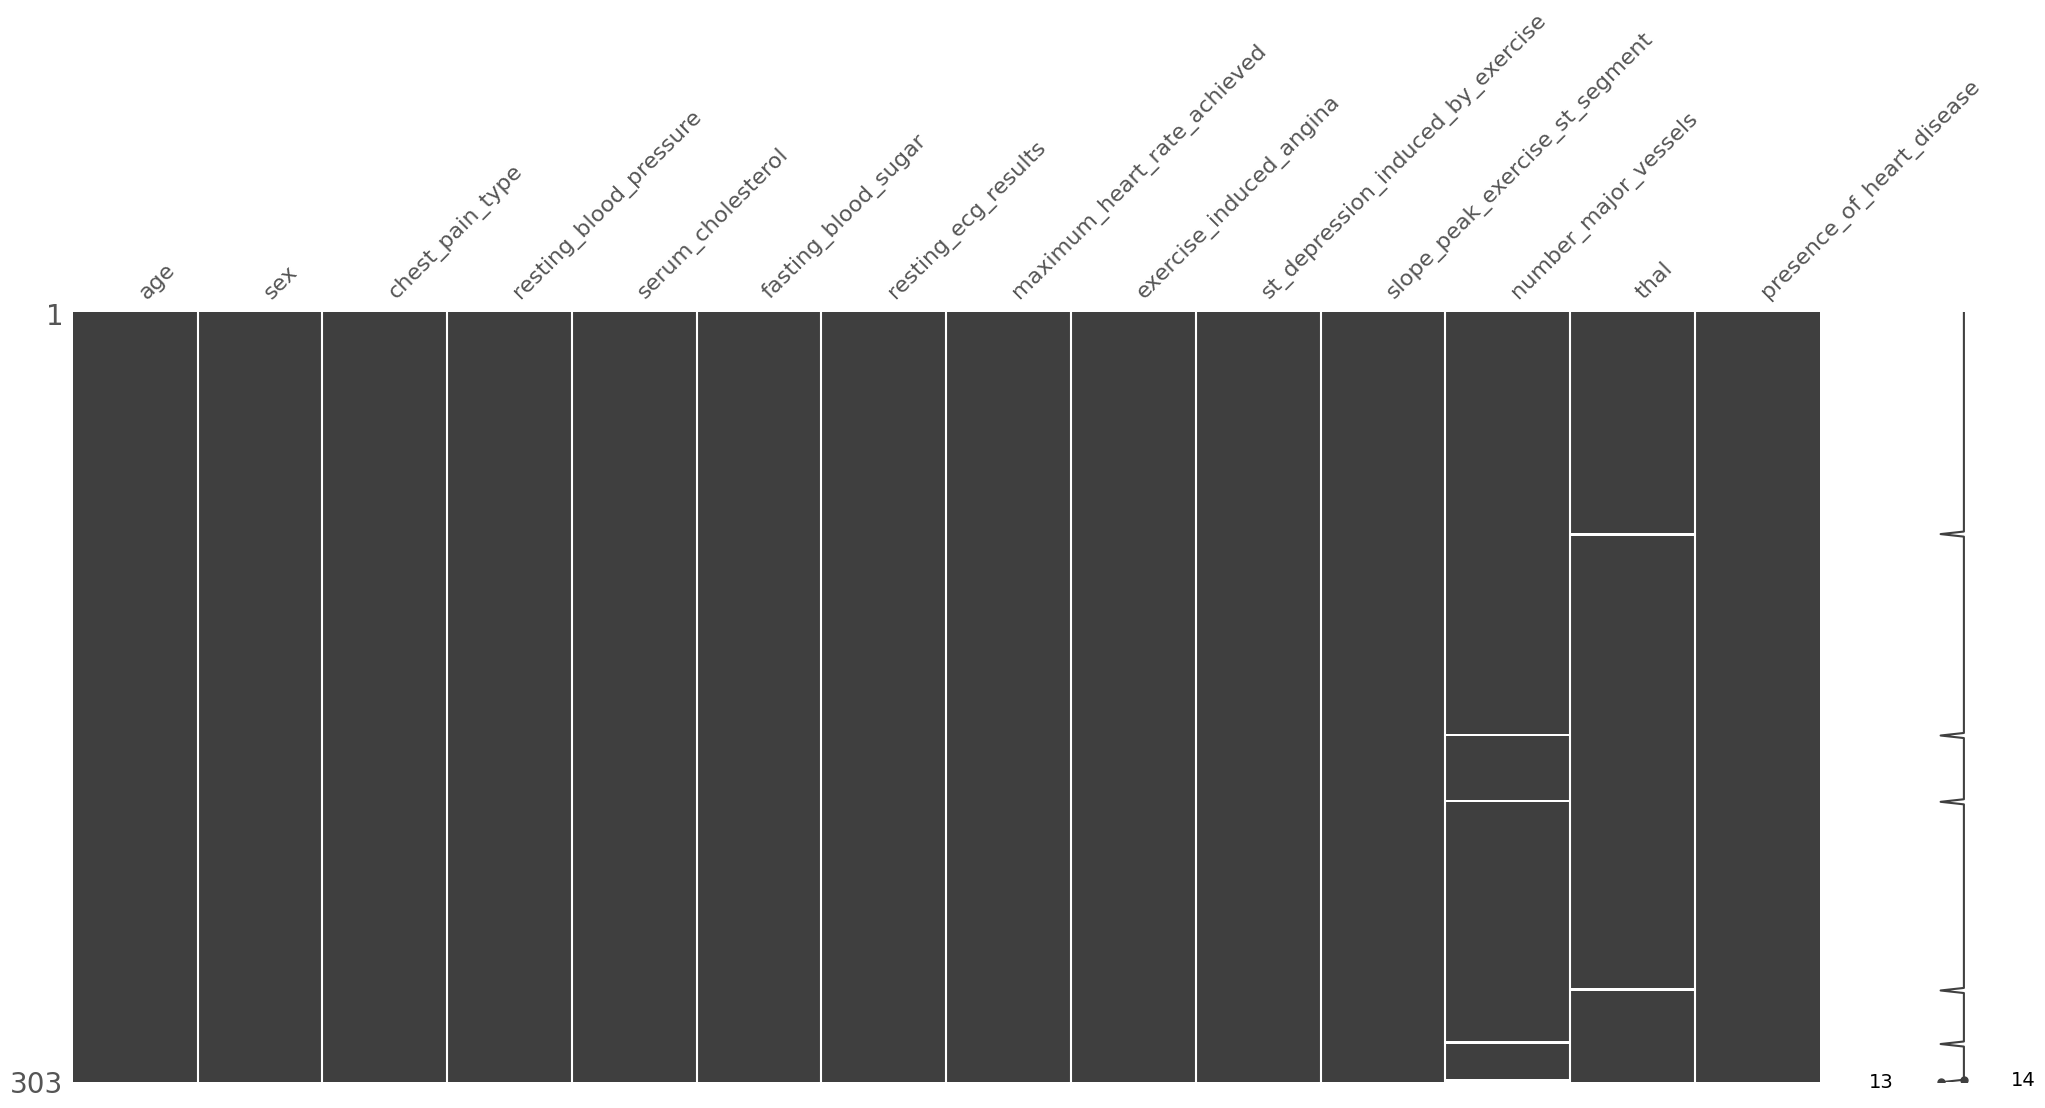

In [139]:
import missingno as msno
msno.matrix(df)

In [140]:
df.duplicated().sum()

np.int64(0)

In [141]:
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
  df.dropna(inplace=True)
  df.drop_duplicates(inplace=True)

  return df

In [142]:
clean_data(df)
df.isnull().sum()

,0
age,0
sex,0
chest_pain_type,0
resting_blood_pressure,0
serum_cholesterol,0
fasting_blood_sugar,0
resting_ecg_results,0
maximum_heart_rate_achieved,0
exercise_induced_angina,0
st_depression_induced_by_exercise,0


## Cleaned the Data fixed the null Values  in the dataset

In [143]:
numeric_cols = [
    "age",
    "resting_blood_pressure",
    "serum_cholesterol",
    "maximum_heart_rate_achieved",
    "st_depression_induced_by_exercise",
    "number_major_vessels",
    "presence_of_heart_disease"
]
numeric_cols

['age',
 'resting_blood_pressure',
 'serum_cholesterol',
 'maximum_heart_rate_achieved',
 'st_depression_induced_by_exercise',
 'number_major_vessels',
 'presence_of_heart_disease']

In [144]:
def plot_features(df: pd.DataFrame, types: list = ["int64", "float64"]) -> None:

    for i in numeric_cols:

        fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(20, 4))
        print(i, "column graphs")
        # Histogram + KDE
        sns.histplot(x=df[i], kde=True, bins=10, ax=axes[0])
        axes[0].set_title(f"Histogram of {i}")

        # Boxplot
        sns.boxplot(x=df[i], ax=axes[1])
        axes[1].set_title(f"Boxplot of {i}")

        # Boxen plot
        sns.boxenplot(x=df[i], ax=axes[2])
        axes[2].set_title(f"Boxen of {i}")

        # Violin plot
        sns.violinplot(x=df[i], ax=axes[3])
        axes[3].set_title(f"Violin of {i}")


        # Show the plots
        plt.show()

In [145]:
def custom_barplot(df: pd.DataFrame, categoric_value: str, numeric_value: str, agg_func: str) -> pd.DataFrame:

    # Group by the categorical value and aggregate the numeric value using the specified function
    sorted_df = df.groupby(categoric_value)[numeric_value].agg(agg_func).reset_index().sort_values(numeric_value, ascending=False)

    # Create the bar plot
    sns.barplot(x=categoric_value, y=numeric_value, data=df, estimator=agg_func, order=sorted_df[categoric_value], ci=False)
    plt.xticks(rotation=90)
    plt.show()

    # Return the sorted aggregated dataframe
    return sorted_df

In [146]:
def outlier_thresholds(df: pd.DataFrame, variable: str, q1_thr: float = 0.25, q3_thr: float = 0.75) -> tuple:

    # Calculate the first and third quartiles
    quartile1 = df[variable].quantile(q1_thr)
    quartile3 = df[variable].quantile(q3_thr)

    # Compute the Interquartile Range (IQR)
    interquantile_range = quartile3 - quartile1

    # Calculate the upper and lower limits for outliers
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range

    # Print the limits
    print(f"low_limit: {low_limit}, up_limit: {up_limit}")

    # Return the calculated limits
    return low_limit, up_limit

In [147]:
def replace_with_thresholds(df: pd.DataFrame, variable: str) -> pd.DataFrame:

    # Get the low and up limits for outlier detection
    low_limit, up_limit = outlier_thresholds(df, variable)
    if df[variable].astype == int:
      low_limit = int(low_limit)
      up_limit = int(up_limit)

    # Count how many values are above the upper limit and below the lower limit
    num_replacements_upper = df[df[variable] > up_limit][variable].count()
    num_replacements_lower = df[df[variable] < low_limit][variable].count()

    # Replace outliers with respective limits
    df.loc[df[variable] > up_limit, variable] = up_limit
    if df[variable].min() > 0:  # Check if the minimum value is positive
        df.loc[df[variable] < low_limit, variable] = low_limit

    # Print how many values were replaced
    print(f"{num_replacements_upper} values replaced with the upper limit, "
          f"{num_replacements_lower} values replaced with the lower limit.")

    # Return the modified dataframe
    return df

In [148]:
def describe_feature(df: pd.DataFrame, feature: str) -> pd.DataFrame:
    print(f"Data type: {df[feature].dtypes}")
    return df[[feature]].describe().T

In [149]:
def describe_categorical_feature(df: pd.DataFrame, feature: str, normalize: bool = False) -> pd.DataFrame:

    print(f"Data type: {df[feature].dtypes}")
    return df[feature].value_counts(normalize=normalize).reset_index()

In [150]:
def one_hot_encoding(df: pd.DataFrame, feature: str) -> pd.DataFrame:
  category_one_hot = pd.get_dummies(df[feature]).astype(int)
  df.drop(feature, axis=1,inplace=True)
  df = pd.concat([df,category_one_hot], axis=1)
  return df

In [151]:
def show_outliers(df: pd.DataFrame, feature: str, low_limit: float, up_limit: float, head_num: int = 5) -> pd.DataFrame:

    df = df[(df[feature] < low_limit) | (df[feature] > up_limit)]
    print(f"There are {len(df)} outliers in the dataset.")
    return df.head(head_num)

In [152]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,297.0,54.542088,9.049736,29.0,48.0,56.0,61.0,77.0
resting_blood_pressure,297.0,131.693603,17.762806,94.0,120.0,130.0,140.0,200.0
serum_cholesterol,297.0,247.350168,51.997583,126.0,211.0,243.0,276.0,564.0
maximum_heart_rate_achieved,297.0,149.599327,22.941562,71.0,133.0,153.0,166.0,202.0
st_depression_induced_by_exercise,297.0,1.055556,1.166123,0.0,0.0,0.8,1.6,6.2
number_major_vessels,297.0,0.676768,0.938965,0.0,0.0,0.0,1.0,3.0
presence_of_heart_disease,297.0,0.279461,0.449492,0.0,0.0,0.0,1.0,1.0


age column graphs


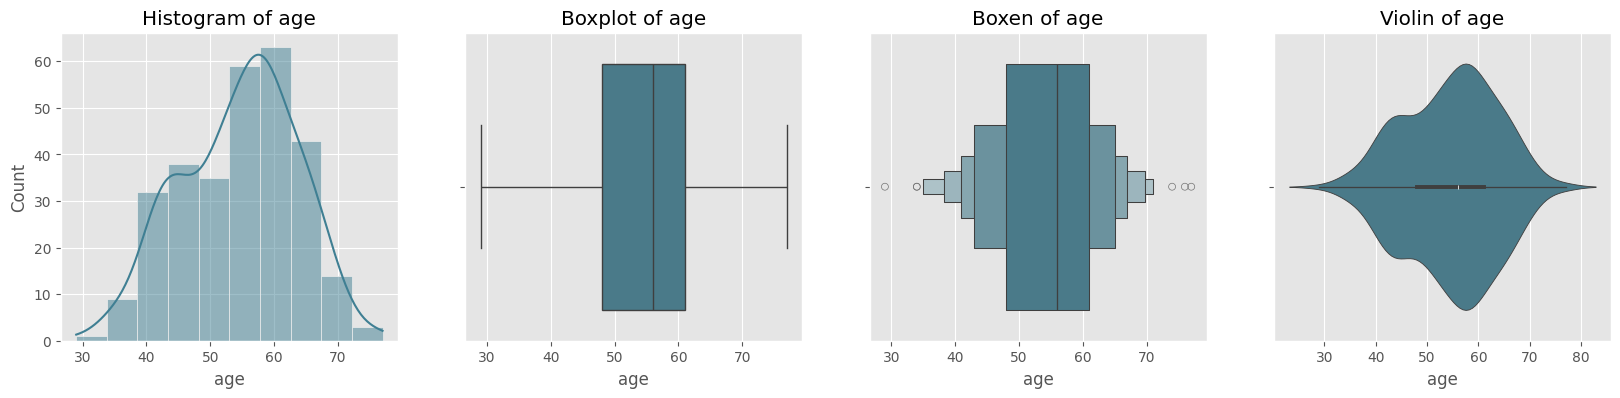

resting_blood_pressure column graphs


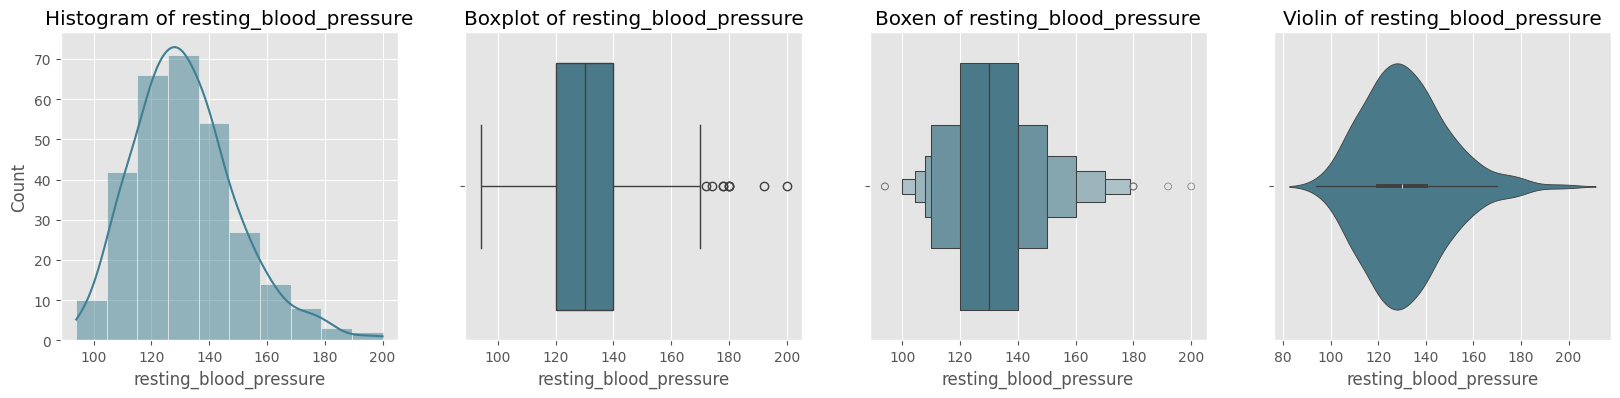

serum_cholesterol column graphs


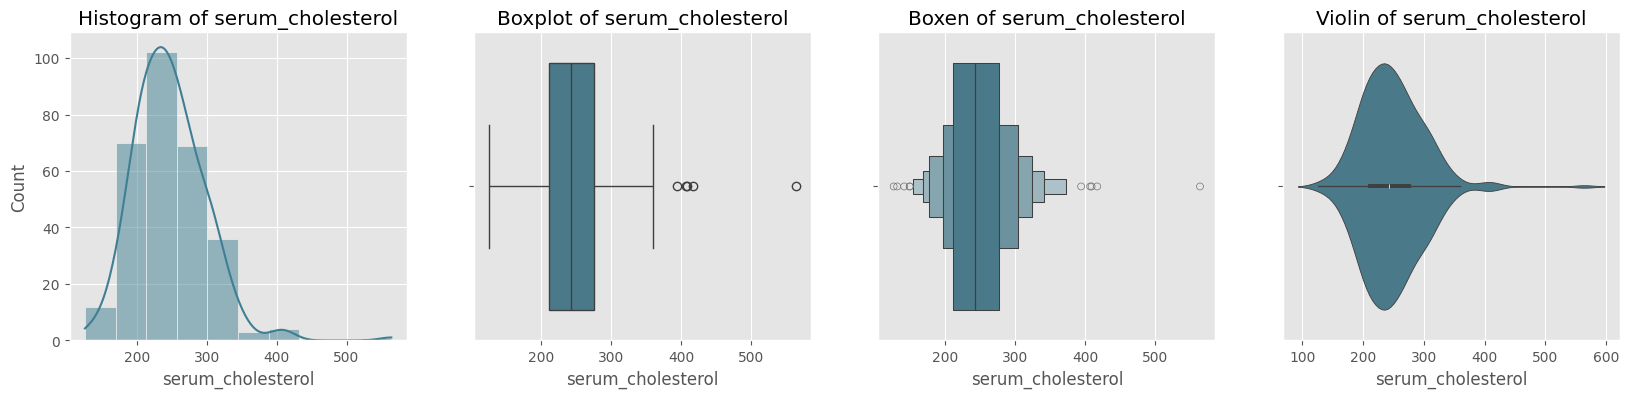

maximum_heart_rate_achieved column graphs


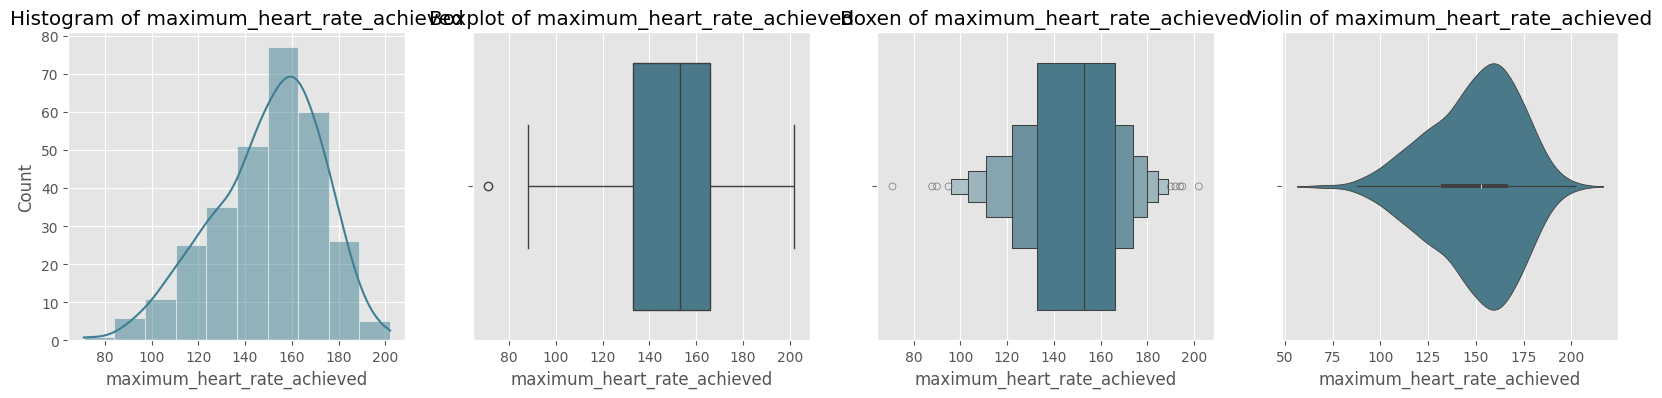

st_depression_induced_by_exercise column graphs


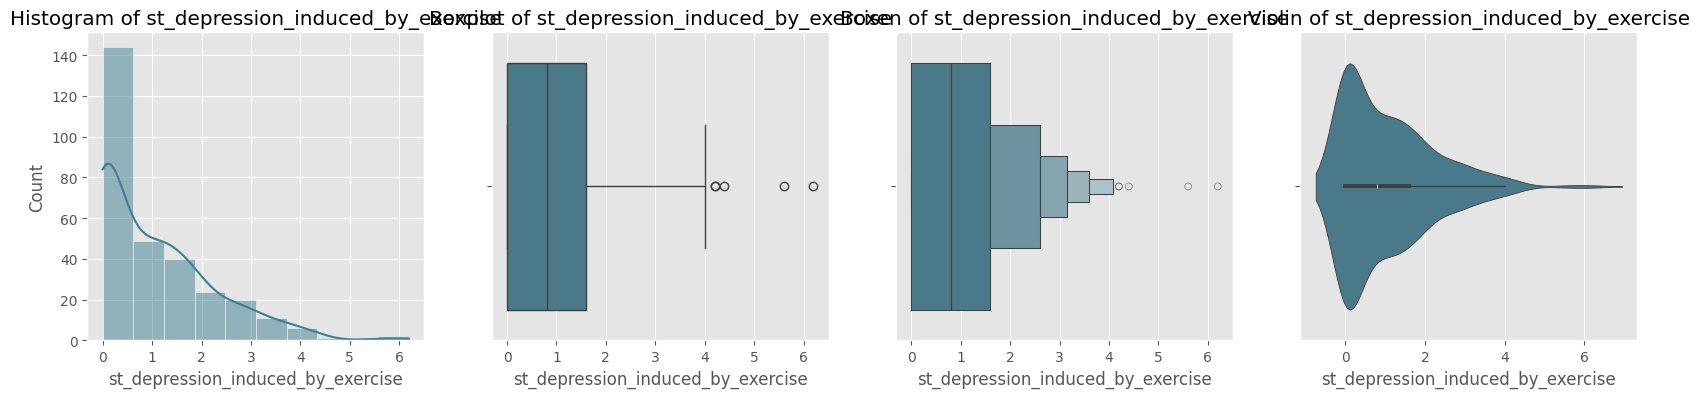

number_major_vessels column graphs


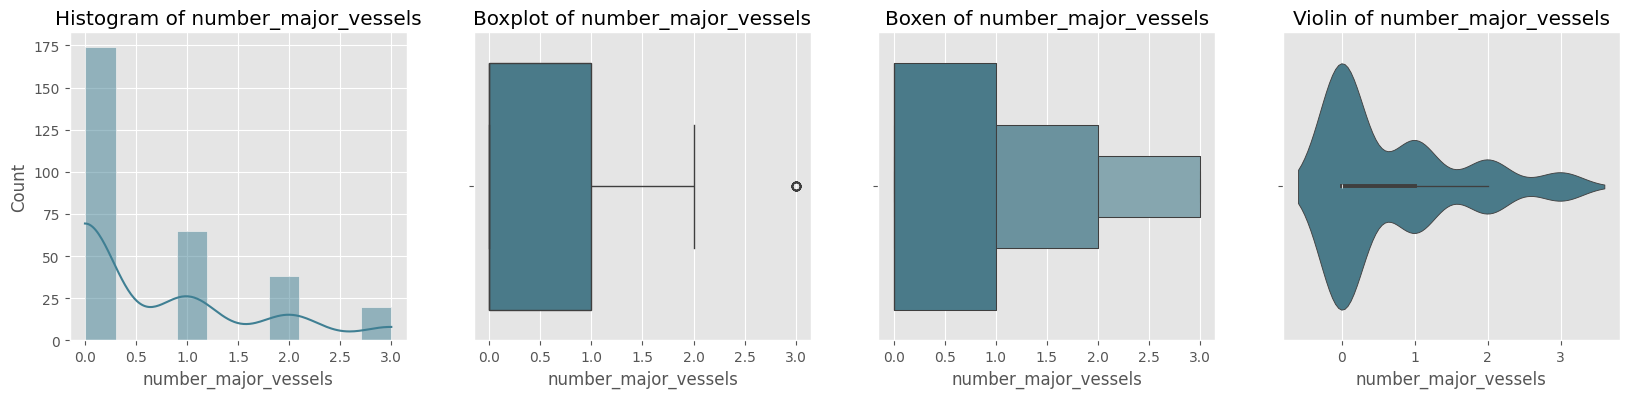

presence_of_heart_disease column graphs


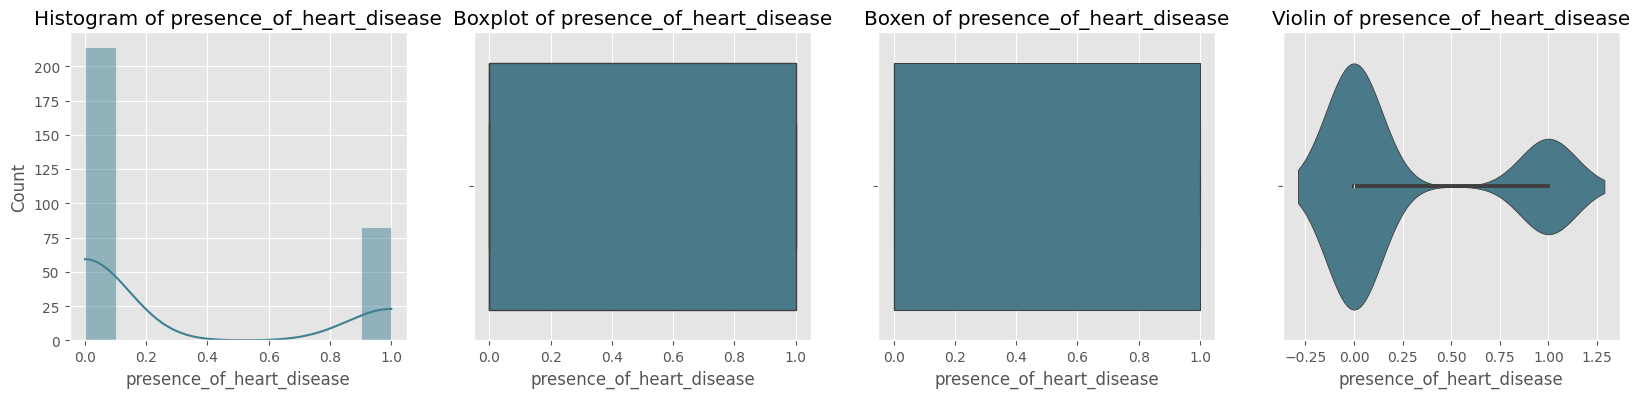

In [153]:
plot_features(df[numeric_cols])

### Age, Resting_blood_pressure are normally distributed where as serun_colestrol and maximum_heartrate_achived are right and left skewed repectively and st_depression_induced_by_exercise are highly left skewed

In [154]:
describe_feature(df, "age")

Data type: int64


,count,mean,std,min,25%,50%,75%,max
age,297.0,54.542088,9.049736,29.0,48.0,56.0,61.0,77.0


In [155]:
low_limit, up_limit = outlier_thresholds(df, "age")
show_outliers(df,"age", low_limit, up_limit)

low_limit: 28.5, up_limit: 80.5
There are 0 outliers in the dataset.


,age,sex,chest_pain_type,resting_blood_pressure,serum_cholesterol,fasting_blood_sugar,resting_ecg_results,maximum_heart_rate_achieved,exercise_induced_angina,st_depression_induced_by_exercise,slope_peak_exercise_st_segment,number_major_vessels,thal,presence_of_heart_disease


In [156]:
df = replace_with_thresholds(df, "age")

low_limit: 28.5, up_limit: 80.5
0 values replaced with the upper limit, 0 values replaced with the lower limit.


In [157]:
describe_feature(df,"resting_blood_pressure")

Data type: int64


,count,mean,std,min,25%,50%,75%,max
resting_blood_pressure,297.0,131.693603,17.762806,94.0,120.0,130.0,140.0,200.0


In [158]:
low_limit, up_limit = outlier_thresholds(df, "resting_blood_pressure")
show_outliers(df,"resting_blood_pressure", low_limit, up_limit)

low_limit: 90.0, up_limit: 170.0
There are 9 outliers in the dataset.


,age,sex,chest_pain_type,resting_blood_pressure,serum_cholesterol,fasting_blood_sugar,resting_ecg_results,maximum_heart_rate_achieved,exercise_induced_angina,st_depression_induced_by_exercise,slope_peak_exercise_st_segment,number_major_vessels,thal,presence_of_heart_disease
14,52.0,1,cp_non_anginal_pain,172,199,1,ecg_normal,162,0,0.5,slope_upsloping,0.0,thal_reversable_defect,0
83,68.0,1,cp_non_anginal_pain,180,274,1,ecg_left_ventricular_hypertrophy,150,1,1.6,slope_flat,0.0,thal_reversable_defect,1
126,56.0,0,cp_asymptomatic,200,288,1,ecg_left_ventricular_hypertrophy,133,1,4.0,slope_downsloping,2.0,thal_reversable_defect,1
172,59.0,0,cp_asymptomatic,174,249,0,ecg_normal,143,1,0.0,slope_flat,0.0,thal_normal,0
183,59.0,1,cp_typical_angina,178,270,0,ecg_left_ventricular_hypertrophy,145,0,4.2,slope_downsloping,0.0,thal_reversable_defect,0


In [159]:
df = replace_with_thresholds(df, "resting_blood_pressure")

low_limit: 90.0, up_limit: 170.0
9 values replaced with the upper limit, 0 values replaced with the lower limit.


9 Outliers found in the resting_blood_pressure column and are succesfully adjusted

In [160]:
describe_feature(df,"serum_cholesterol")

Data type: int64


,count,mean,std,min,25%,50%,75%,max
serum_cholesterol,297.0,247.350168,51.997583,126.0,211.0,243.0,276.0,564.0


In [161]:
low_limit, up_limit = outlier_thresholds(df, "serum_cholesterol")
show_outliers(df,"serum_cholesterol", low_limit, up_limit)

low_limit: 113.5, up_limit: 373.5
There are 5 outliers in the dataset.


,age,sex,chest_pain_type,resting_blood_pressure,serum_cholesterol,fasting_blood_sugar,resting_ecg_results,maximum_heart_rate_achieved,exercise_induced_angina,st_depression_induced_by_exercise,slope_peak_exercise_st_segment,number_major_vessels,thal,presence_of_heart_disease
48,65.0,0,cp_non_anginal_pain,140,417,1,ecg_left_ventricular_hypertrophy,157,0,0.8,slope_upsloping,1.0,thal_normal,0
121,63.0,0,cp_asymptomatic,150,407,0,ecg_left_ventricular_hypertrophy,154,0,4.0,slope_flat,3.0,thal_reversable_defect,1
152,67.0,0,cp_non_anginal_pain,115,564,0,ecg_left_ventricular_hypertrophy,160,0,1.6,slope_flat,0.0,thal_reversable_defect,0
173,62.0,0,cp_asymptomatic,140,394,0,ecg_left_ventricular_hypertrophy,157,0,1.2,slope_flat,0.0,thal_normal,0
181,56.0,0,cp_asymptomatic,134,409,0,ecg_left_ventricular_hypertrophy,150,1,1.9,slope_flat,2.0,thal_reversable_defect,1


In [162]:
df = replace_with_thresholds(df, "serum_cholesterol")

low_limit: 113.5, up_limit: 373.5
5 values replaced with the upper limit, 0 values replaced with the lower limit.


5 Outliers found in the serun_cholesterol column and are succesfully adjusted

In [163]:
describe_feature(df,"maximum_heart_rate_achieved")

Data type: int64


,count,mean,std,min,25%,50%,75%,max
maximum_heart_rate_achieved,297.0,149.599327,22.941562,71.0,133.0,153.0,166.0,202.0


In [164]:
low_limit, up_limit = outlier_thresholds(df, "maximum_heart_rate_achieved")
show_outliers(df, "maximum_heart_rate_achieved",low_limit, up_limit)

low_limit: 83.5, up_limit: 215.5
There are 1 outliers in the dataset.


,age,sex,chest_pain_type,resting_blood_pressure,serum_cholesterol,fasting_blood_sugar,resting_ecg_results,maximum_heart_rate_achieved,exercise_induced_angina,st_depression_induced_by_exercise,slope_peak_exercise_st_segment,number_major_vessels,thal,presence_of_heart_disease
245,67.0,1,cp_asymptomatic,120,237.0,0,ecg_normal,71,0,1.0,slope_flat,0.0,thal_normal,1


In [165]:
df = replace_with_thresholds(df, "maximum_heart_rate_achieved")

low_limit: 83.5, up_limit: 215.5
0 values replaced with the upper limit, 1 values replaced with the lower limit.


1 Outlier detected in the data is succesfully adjusted

In [166]:
describe_feature(df, "st_depression_induced_by_exercise")

Data type: float64


,count,mean,std,min,25%,50%,75%,max
st_depression_induced_by_exercise,297.0,1.055556,1.166123,0.0,0.0,0.8,1.6,6.2


In [167]:
low_limit, up_limit = outlier_thresholds(df, "st_depression_induced_by_exercise")
show_outliers(df, "st_depression_induced_by_exercise",low_limit, up_limit)

low_limit: -2.4000000000000004, up_limit: 4.0
There are 5 outliers in the dataset.


,age,sex,chest_pain_type,resting_blood_pressure,serum_cholesterol,fasting_blood_sugar,resting_ecg_results,maximum_heart_rate_achieved,exercise_induced_angina,st_depression_induced_by_exercise,slope_peak_exercise_st_segment,number_major_vessels,thal,presence_of_heart_disease
91,62.0,0,cp_asymptomatic,160,164.0,0,ecg_left_ventricular_hypertrophy,145.0,0,6.2,slope_downsloping,3.0,thal_reversable_defect,1
123,55.0,1,cp_asymptomatic,140,217.0,0,ecg_normal,111.0,1,5.6,slope_downsloping,0.0,thal_reversable_defect,1
183,59.0,1,cp_typical_angina,170,270.0,0,ecg_left_ventricular_hypertrophy,145.0,0,4.2,slope_downsloping,0.0,thal_reversable_defect,0
191,51.0,1,cp_asymptomatic,140,298.0,0,ecg_normal,122.0,1,4.2,slope_flat,3.0,thal_reversable_defect,1
285,58.0,1,cp_asymptomatic,114,318.0,0,ecg_st_t_wave_abnormality,140.0,0,4.4,slope_downsloping,3.0,thal_fixed_defect,1


In [168]:
df = replace_with_thresholds(df, "st_depression_induced_by_exercise")

low_limit: -2.4000000000000004, up_limit: 4.0
5 values replaced with the upper limit, 0 values replaced with the lower limit.


5 ouliers detected in the st_depression_induced_by_exercise are ajusted succesfully

In [169]:
describe_feature(df, "number_major_vessels")

Data type: float64


,count,mean,std,min,25%,50%,75%,max
number_major_vessels,297.0,0.676768,0.938965,0.0,0.0,0.0,1.0,3.0


age column graphs


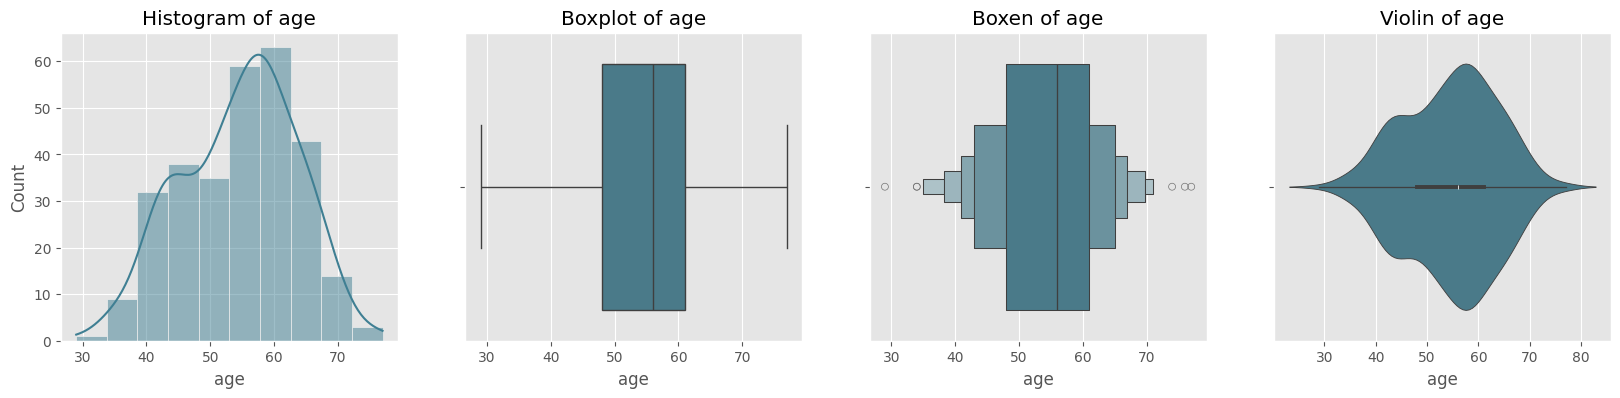

resting_blood_pressure column graphs


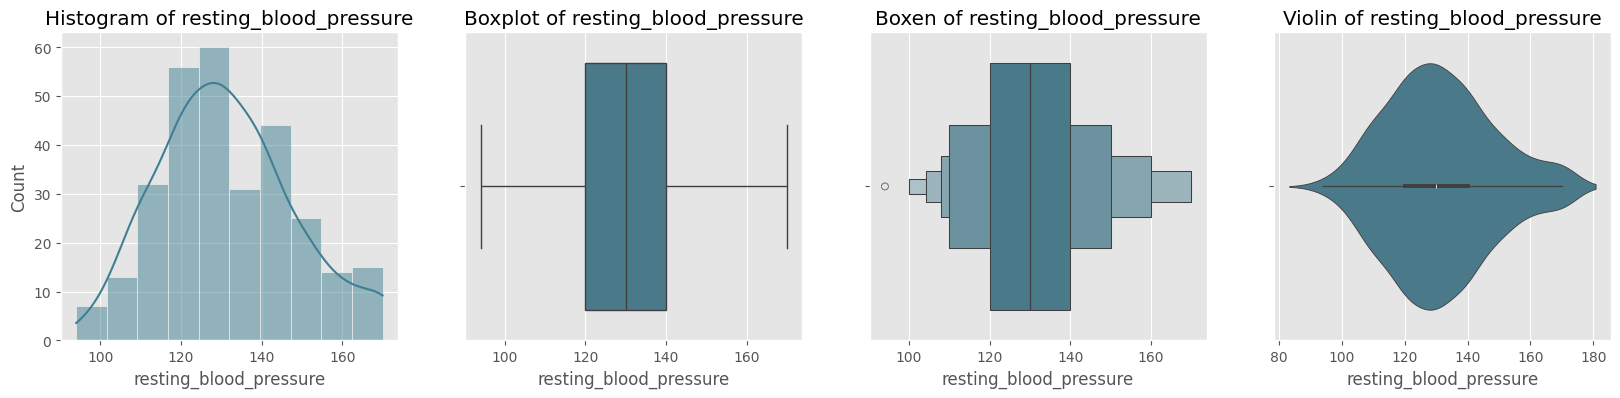

serum_cholesterol column graphs


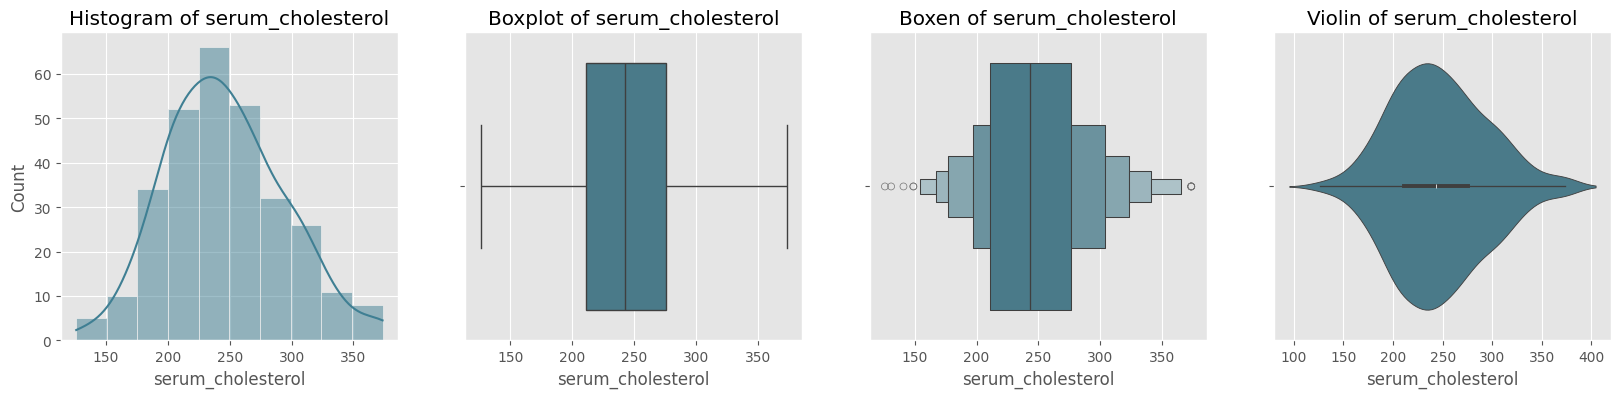

maximum_heart_rate_achieved column graphs


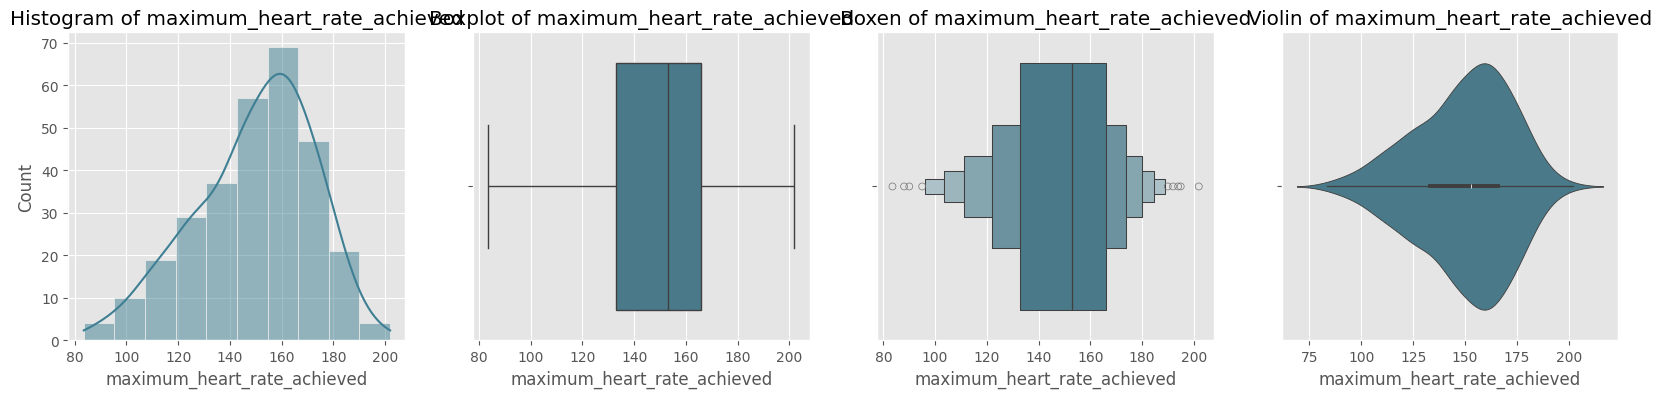

st_depression_induced_by_exercise column graphs


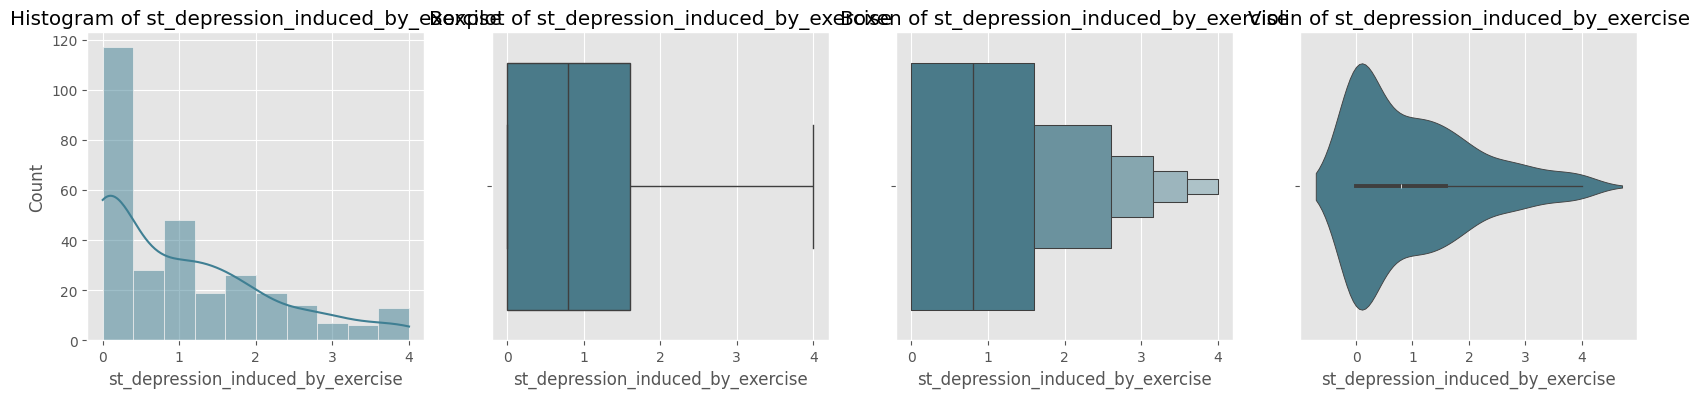

number_major_vessels column graphs


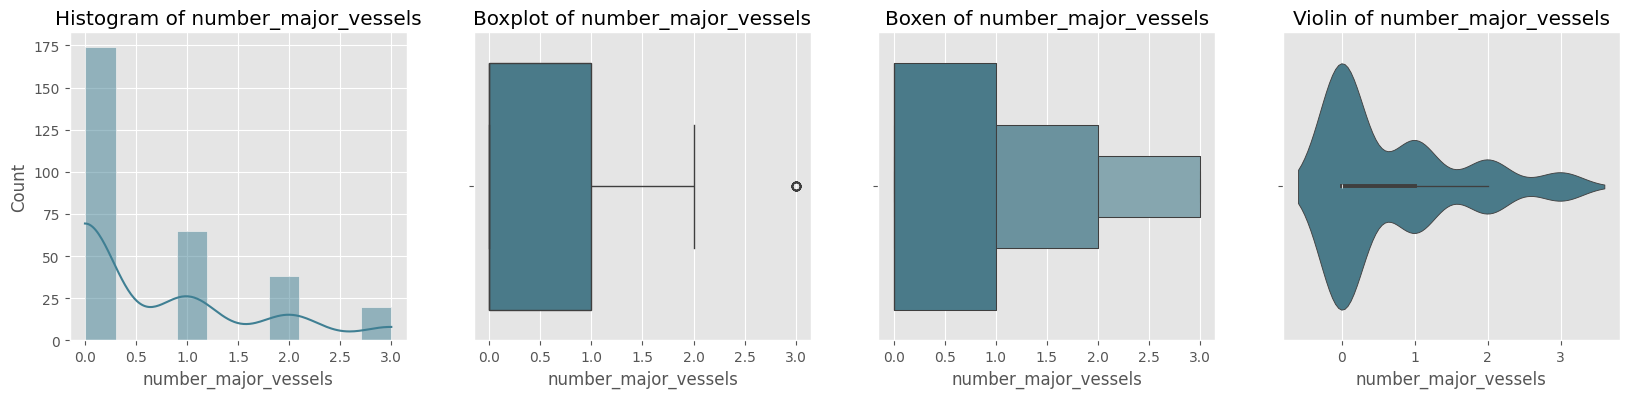

presence_of_heart_disease column graphs


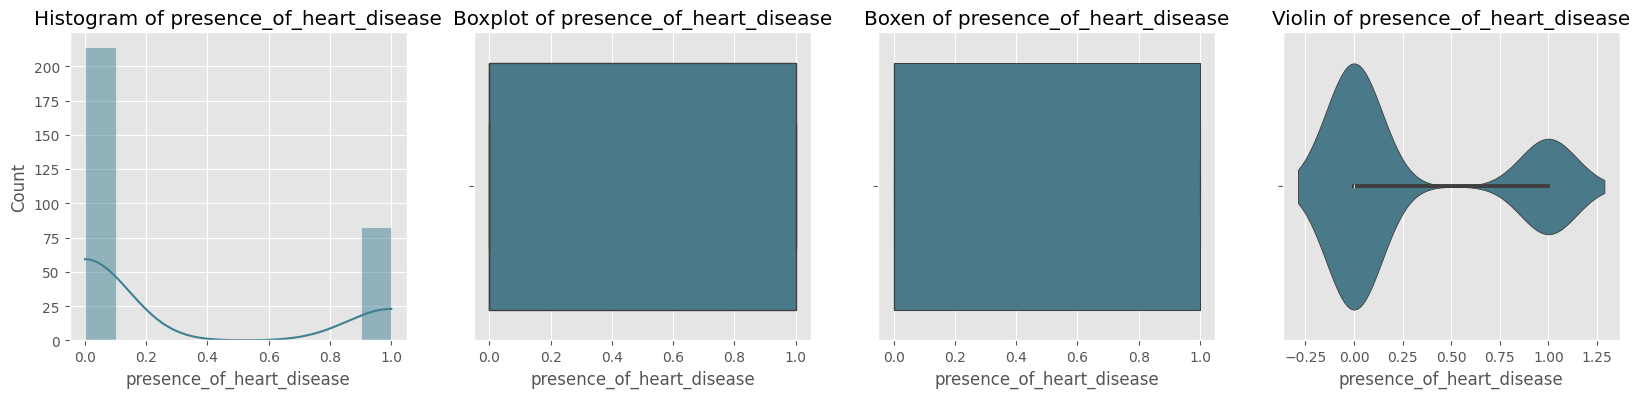

In [170]:
plot_features(df[numeric_cols])

In [171]:
for feature in categorical_cols:
    print(df[[feature]].value_counts(), "\n")

sex
1      201
0       96
Name: count, dtype: int64 

chest_pain_type    
cp_asymptomatic        142
cp_non_anginal_pain     83
cp_atypical_angina      49
cp_typical_angina       23
Name: count, dtype: int64 

resting_ecg_results             
ecg_normal                          147
ecg_left_ventricular_hypertrophy    146
ecg_st_t_wave_abnormality             4
Name: count, dtype: int64 

fasting_blood_sugar
0                      254
1                       43
Name: count, dtype: int64 

exercise_induced_angina
0                          200
1                           97
Name: count, dtype: int64 

thal                  
thal_normal               164
thal_reversable_defect    115
thal_fixed_defect          18
Name: count, dtype: int64 

slope_peak_exercise_st_segment
slope_upsloping                   139
slope_flat                        137
slope_downsloping                  21
Name: count, dtype: int64 



In [172]:
describe_categorical_feature(df, "sex")

Data type: int64


,sex,count
0,1,201
1,0,96


In [173]:

describe_categorical_feature(df, "chest_pain_type")

Data type: object


,chest_pain_type,count
0,cp_asymptomatic,142
1,cp_non_anginal_pain,83
2,cp_atypical_angina,49
3,cp_typical_angina,23


In [174]:
df = one_hot_encoding(df, "chest_pain_type")

Chest pain type

Refers to the types of chest pain. As seen in the descriptions, there is no hierarchy of size or magnitude among the chest pain types. These are nominal categorical variables. Therefore, applying one-hot encoding would be more appropriate.

1: Typical angina:

Chest pain that typically occurs during physical activity or stress, and subsides with rest or nitroglycerin.
It is considered related to the heart.

2: Atypical angina:
Similar to typical angina, but with different symptoms and triggers.
It may or may not be related to the heart.

3: Non-anginal pain:
Chest pain, but not typical of angina and usually not related to the heart.
It could be caused by muscles or the skeletal system, for example.

4: Asymptomatic:
Conditions such as heart disease without chest pain.

In [175]:
describe_categorical_feature(df, "resting_ecg_results")

Data type: object


,resting_ecg_results,count
0,ecg_normal,147
1,ecg_left_ventricular_hypertrophy,146
2,ecg_st_t_wave_abnormality,4


In [176]:
describe_categorical_feature(df, "resting_ecg_results")

Data type: object


,resting_ecg_results,count
0,ecg_normal,147
1,ecg_left_ventricular_hypertrophy,146
2,ecg_st_t_wave_abnormality,4


In [177]:
df = one_hot_encoding(df, "resting_ecg_results")

resting_ecg_results

Represents the resting ECG results. As seen from the descriptions, there is no hierarchical relationship between them. These are nominal categorical variables. Therefore, applying one-hot encoding is more appropriate.
0: Normal:

A normal ST-T wave pattern with no abnormalities on the heart's electrocardiogram (EKG).

1: ST-T Wave Abnormality: Abnormalities are present in the ST-T wave; this may include T-wave inversion and/or an elevation or depression of the ST segment greater than 0.05 mV.

2: Possible or Definite Left Ventricular Hypertrophy: An EKG finding showing left ventricular hypertrophy according to the Estes criteria.

dropped the less significant rows in the dataset

In [178]:
describe_categorical_feature(df, "exercise_induced_angina")

Data type: int64


,exercise_induced_angina,count
0,0,200
1,1,97


exercise_induced_angina

Angina (chest pain) induced by exercise. This refers to chest pain occurring during physical activity. Since it is encoded as 1 if pain occurs after exercise and 0 if not, no further processing is required.

In [179]:
describe_categorical_feature(df, "thal")

Data type: object


,thal,count
0,thal_normal,164
1,thal_reversable_defect,115
2,thal_fixed_defect,18


thal

thal: Refers to the results of the Thallium stress test. This test is used to assess blood flow and oxygenation in the heart muscle. The test is performed to examine the adequacy of blood flow in certain areas of the heart muscle. There is no inherent order or ranking between these values. They are nominal categorical variables. Therefore, one-hot encoding is the most appropriate method to apply.

Thallium Stress Test Results:

3: Normal:

This indicates no abnormalities in blood flow to the heart muscle.
6: Fixed Defect:

A permanent defect or damage in the heart muscle that does not improve with exercise or medication. This represents a permanent disorder in specific areas of the heart.
7: Reversible Defect:

A temporary defect or damage in the heart muscle that can improve with exercise or medication. This indicates a condition that can improve with treatment or exercise.

In [180]:
df = one_hot_encoding(df, "thal")

dropped the less significant row from the dataset

In [181]:
describe_categorical_feature(df, "slope_peak_exercise_st_segment")

Data type: object


,slope_peak_exercise_st_segment,count
0,slope_upsloping,139
1,slope_flat,137
2,slope_downsloping,21


In [182]:
df = one_hot_encoding(df, "slope_peak_exercise_st_segment")

In [183]:
df.head()

,age,sex,resting_blood_pressure,serum_cholesterol,fasting_blood_sugar,maximum_heart_rate_achieved,exercise_induced_angina,st_depression_induced_by_exercise,number_major_vessels,presence_of_heart_disease,cp_asymptomatic,cp_atypical_angina,cp_non_anginal_pain,cp_typical_angina,ecg_left_ventricular_hypertrophy,ecg_normal,ecg_st_t_wave_abnormality,thal_fixed_defect,thal_normal,thal_reversable_defect,slope_downsloping,slope_flat,slope_upsloping
0,63.0,1,145,233.0,1,150.0,0,2.3,0.0,0,0,0,0,1,1,0,0,1,0,0,1,0,0
1,67.0,1,160,286.0,0,108.0,1,1.5,3.0,1,1,0,0,0,1,0,0,0,1,0,0,1,0
2,67.0,1,120,229.0,0,129.0,1,2.6,2.0,0,1,0,0,0,1,0,0,0,0,1,0,1,0
3,37.0,1,130,250.0,0,187.0,0,3.5,0.0,0,0,0,1,0,0,1,0,0,1,0,1,0,0
4,41.0,0,130,204.0,0,172.0,0,1.4,0.0,0,0,1,0,0,1,0,0,0,1,0,0,0,1



## Feature Extraction

### The variables here were extracted after all preprocessing and encoding were done, and a baseline model was created. To facilitate the process management, the model performance was evaluated after each feature extraction and logged in mlflow. Additionally, commits were made for each variable using the git version control system.

### Feature extraction is done to improve the model's performance. The models created in the project have achieved very high scores with the existing features. The data size is very small. Normally, when a new feature is added, increasing the amount of data is a commonly used practice. However, since high scores were achieved with the existing data in this project, adding each feature may lead to overfitting, which is a problem of excessive learning.

In [184]:
age_bins = [-np.inf, 18, 40, 60, np.inf]
age_labels = [0, 1, 2, 3]

df['age_category'] = pd.cut(
    df['age'],
    bins=age_bins,
    labels=age_labels
)

In [185]:
describe_categorical_feature(df, "age_category")

Data type: category


,age_category,count
0,2,201
1,3,79
2,1,17
3,0,0


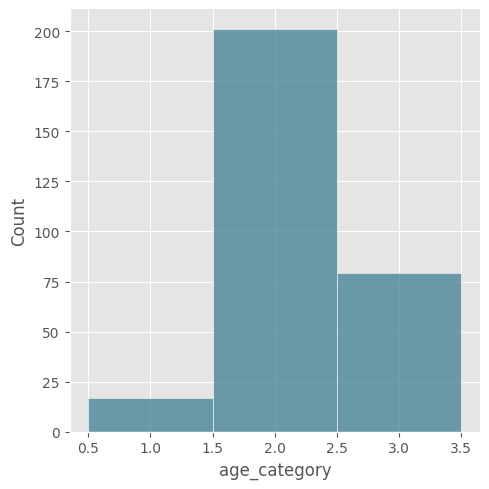

In [186]:
sns.displot(data=df, x='age_category')

In [187]:
df.groupby("age_category")["presence_of_heart_disease"].mean().head().reset_index()

,age_category,presence_of_heart_disease
0,0,NaN
1,1,0.176471
2,2,0.248756
3,3,0.379747


Comparison of the newly created categorical age feature with numerical features.

According to the available dataset:
resting_blood_pressure and serum_cholesterol values are close to each other and tend to increase as age progresses.
maximum_heart_rate_achieved is highest in the 18-40 age group.
st_depression_induced_by_exercise and number_major_vessels values are more concentrated in the 60+ age group.

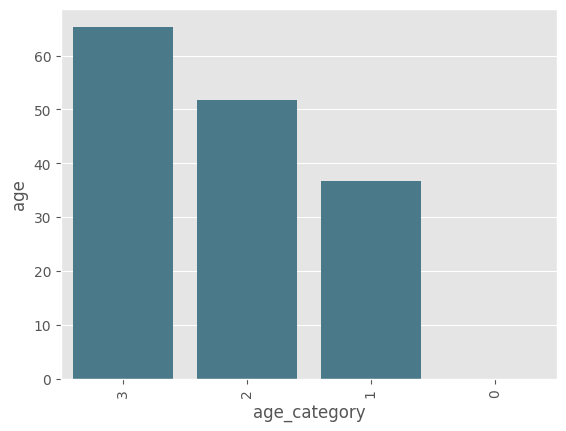

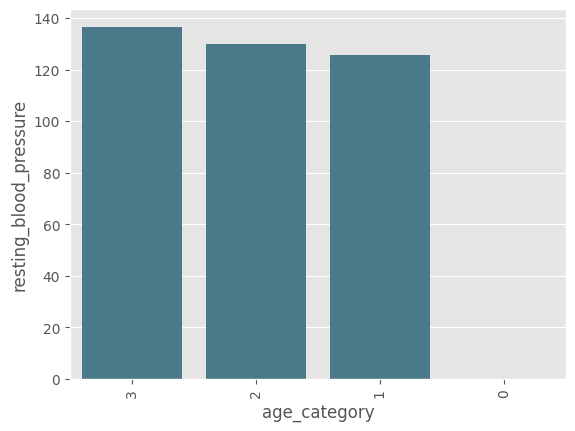

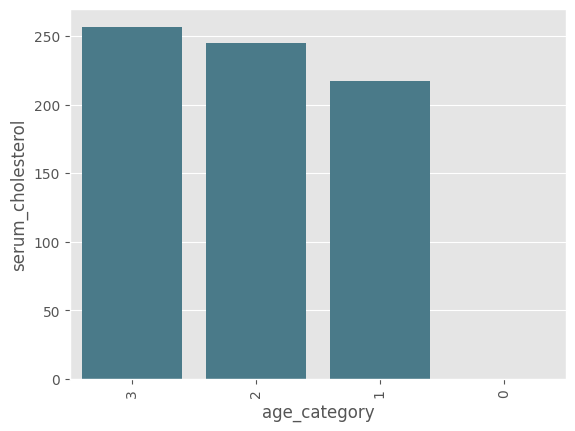

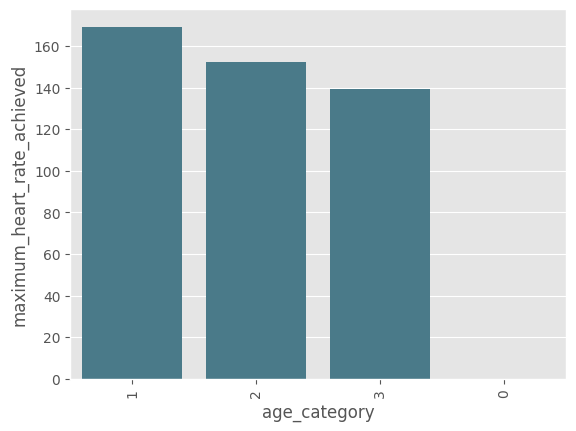

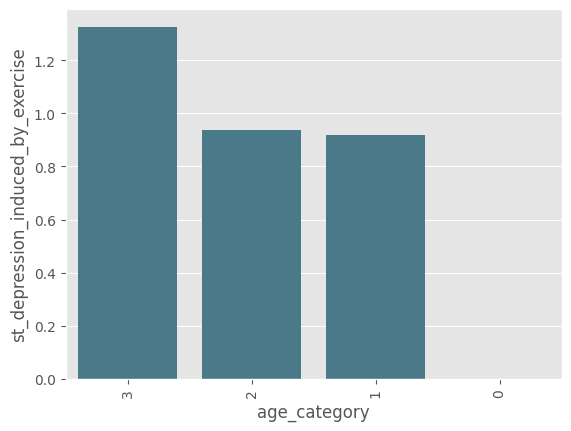

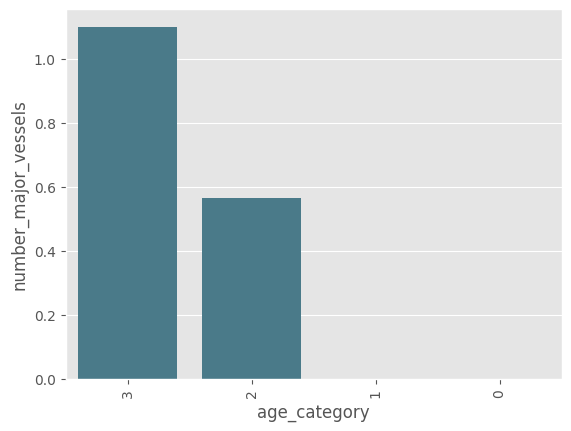

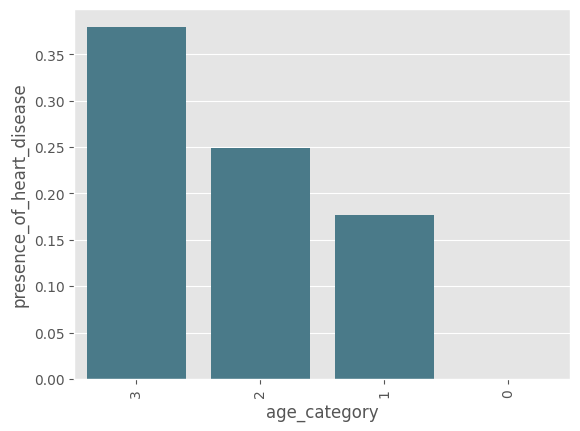

In [188]:
for col in numeric_cols:
  custom_barplot(df, 'age_category', col,agg_func=np.mean )

In [189]:
encoder = OrdinalEncoder(categories=[[0, 1, 2, 3]])
df['age_category'] = encoder.fit_transform(df[['age_category']])
describe_categorical_feature(df, "age_category")

Data type: float64


,age_category,count
0,2.0,201
1,3.0,79
2,1.0,17


In [190]:
describe_feature(df, "maximum_heart_rate_achieved")

Data type: float64


,count,mean,std,min,25%,50%,75%,max
maximum_heart_rate_achieved,297.0,149.641414,22.807957,83.5,133.0,153.0,166.0,202.0


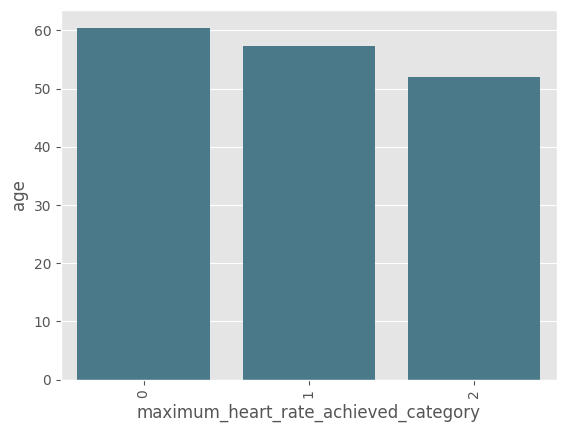

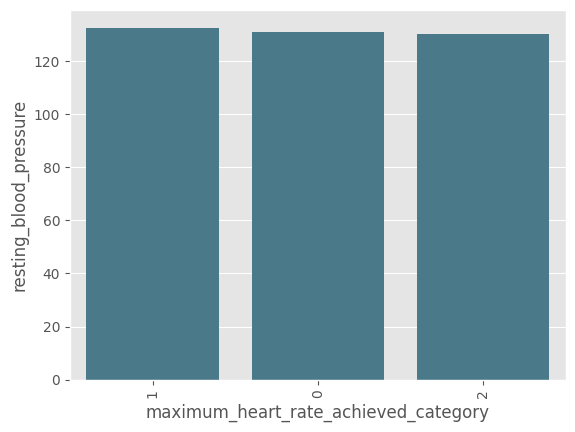

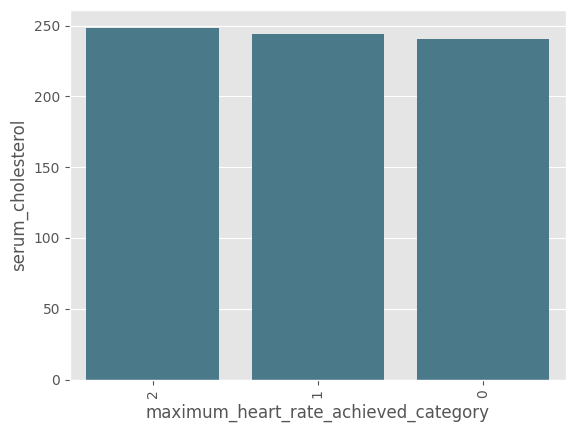

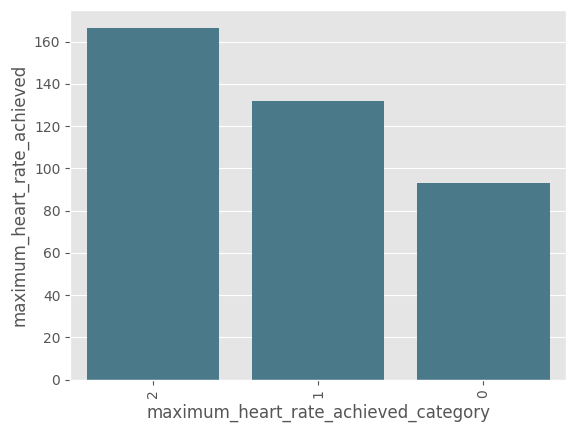

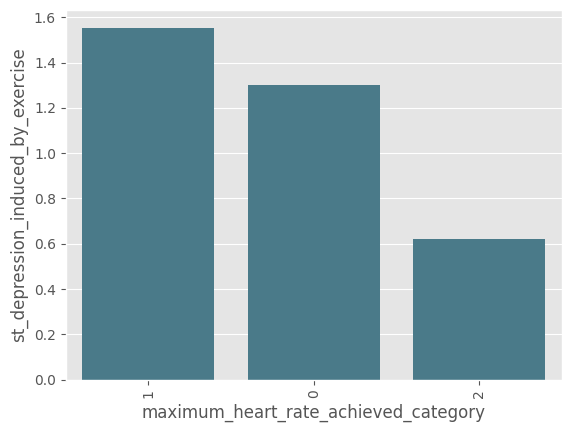

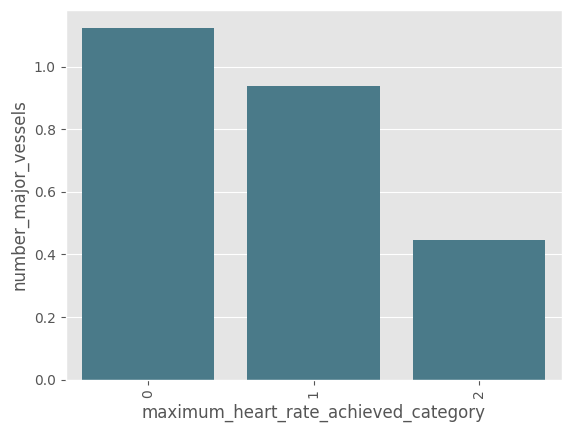

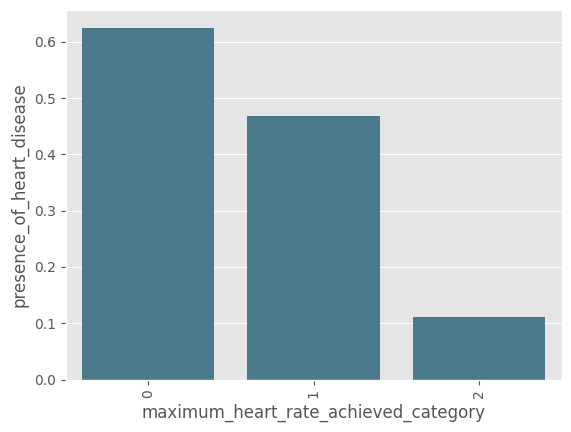

In [191]:
mhr_bins = [-np.inf, 100, 150, np.inf]
mhr_labels = [0, 1, 2]

df['maximum_heart_rate_achieved_category'] = pd.cut(df['maximum_heart_rate_achieved'], bins=mhr_bins, labels=mhr_labels)

for col in numeric_cols:
  custom_barplot(df, 'maximum_heart_rate_achieved_category', col, agg_func=np.mean)

In [192]:
encoder = OrdinalEncoder(categories=[[0, 1, 2]])
df['maximum_heart_rate_achieved_category'] = encoder.fit_transform(df[['maximum_heart_rate_achieved_category']])
describe_categorical_feature(df, "maximum_heart_rate_achieved_category")

Data type: float64


,maximum_heart_rate_achieved_category,count
0,2.0,161
1,1.0,128
2,0.0,8


In [193]:
describe_feature(df, 'serum_cholesterol')

Data type: float64


,count,mean,std,min,25%,50%,75%,max
serum_cholesterol,297.0,246.260943,47.836752,126.0,211.0,243.0,276.0,373.5


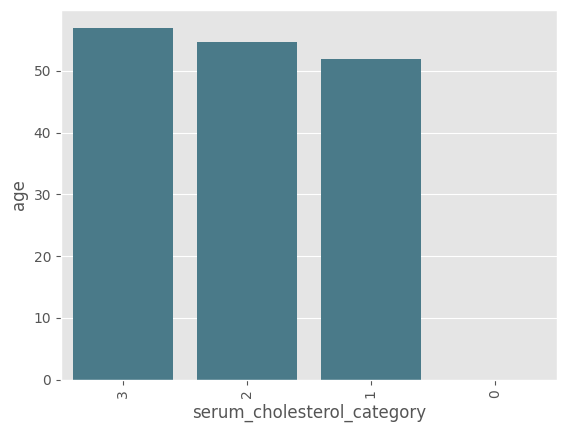

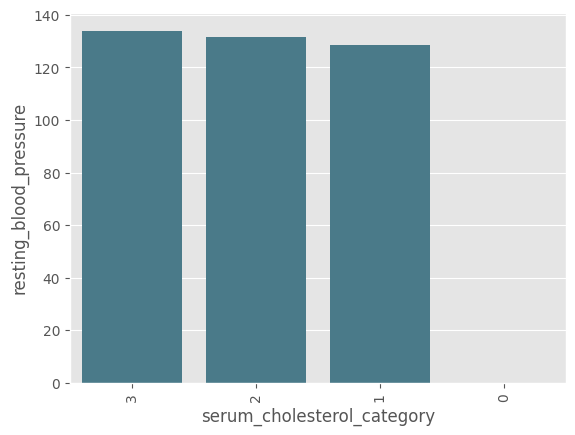

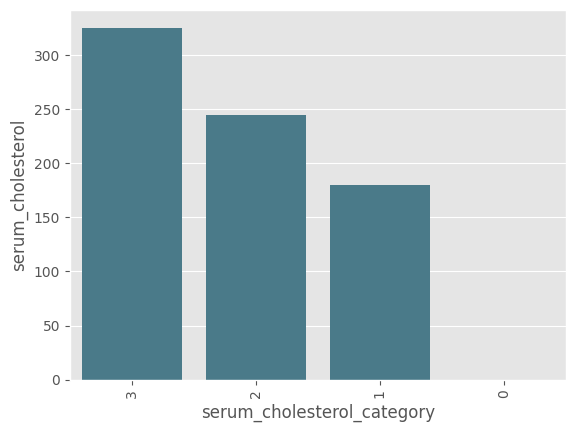

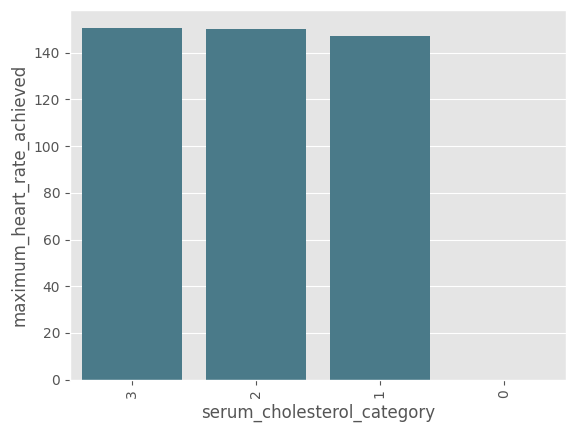

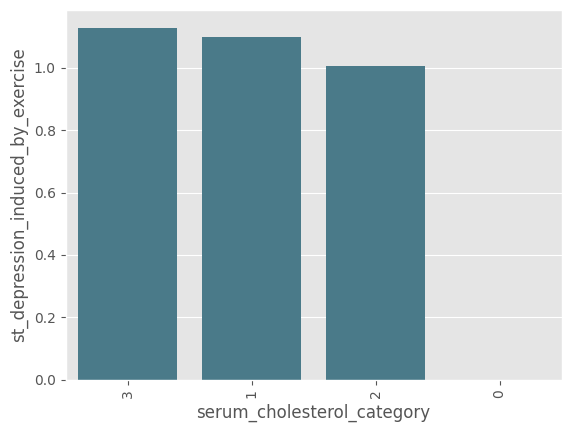

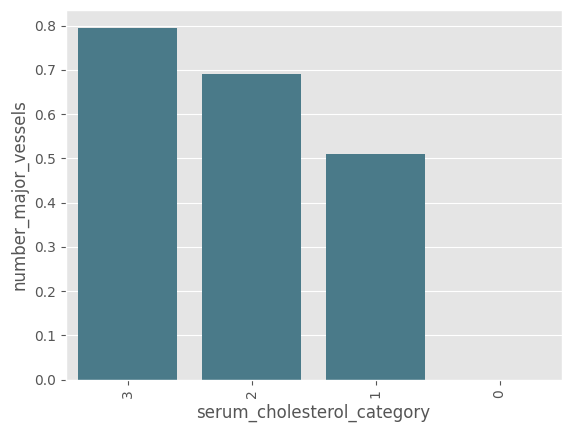

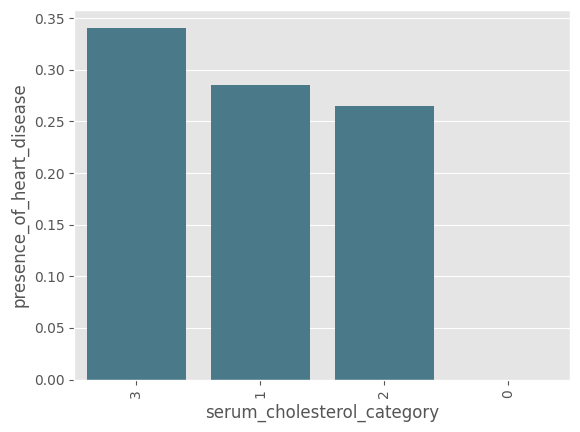

In [194]:
mhr_bins = [-np.inf, 100, 200, 300, np.inf]
mhr_labels = [0, 1, 2, 3]

df['serum_cholesterol_category'] = pd.cut(df['serum_cholesterol'], bins=mhr_bins, labels=mhr_labels)

for col in numeric_cols:
  custom_barplot(df, 'serum_cholesterol_category', col, agg_func=np.mean)

In [195]:
encoder = OrdinalEncoder(categories=[[0, 1, 2, 3]])
df['serum_cholesterol_category'] = encoder.fit_transform(df[['serum_cholesterol_category']])
describe_categorical_feature(df, "serum_cholesterol_category")

Data type: float64


,serum_cholesterol_category,count
0,2.0,204
1,1.0,49
2,3.0,44


Other Added Numerical Features:

Blood Pressure and Cholesterol Ratio

This feature represents the ratio of a person's blood pressure to their cholesterol level. High blood pressure and high cholesterol can increase the risk of heart disease.

BP\_Cholesterol\_Ratio
=
resting\_blood\_pressure
serum\_cholesterol

Heart Rate and Exercise Relationship

This feature measures the relationship between the maximum heart rate and exercise-induced angina. It can be used to assess the risk of heart disease.

HeartRate\_Angina\_Ratio
=
maximum\_heart\_rate\_achieved
1
+
exercise\_induced\_angina

Here, the presence of exercise-induced angina (0 or 1) is added, and +1 is included in the denominator to avoid division by zero.

Exercise-Induced ST Depression and Angina Relationship

ST depression during exercise can indicate heart disease. This feature represents the relationship between ST depression and angina.

ST\_Angina\_Ratio
=
st\_depression\_induced\_by\_exercise
1
+
exercise\_induced\_angina

Total Number of Vessels and Heart Rate Relationship

This feature represents the relationship between maximum heart rate and the number of vessels detected by fluoroscopy. As the number of detected vessels increases, the risk of heart disease increases.

HeartRate\_Vessels\_Ratio
=
maximum\_heart\_rate\_achieved
1
+
number\_major\_vessels


In [196]:
df['bp_cholesterol_ratio'] = df['resting_blood_pressure'] / df['serum_cholesterol']
df['heartrate_angina_ratio'] = df['maximum_heart_rate_achieved'] / (df['exercise_induced_angina'])
df['st_angina_ratio'] = df['st_depression_induced_by_exercise'] / (1 + df['exercise_induced_angina'])
df['heartrate_vessels_ratio'] = df['maximum_heart_rate_achieved'] / (1 + df['number_major_vessels'])
df.head()

,age,sex,resting_blood_pressure,serum_cholesterol,fasting_blood_sugar,maximum_heart_rate_achieved,exercise_induced_angina,st_depression_induced_by_exercise,number_major_vessels,presence_of_heart_disease,cp_asymptomatic,cp_atypical_angina,cp_non_anginal_pain,cp_typical_angina,ecg_left_ventricular_hypertrophy,ecg_normal,ecg_st_t_wave_abnormality,thal_fixed_defect,thal_normal,thal_reversable_defect,slope_downsloping,slope_flat,slope_upsloping,age_category,maximum_heart_rate_achieved_category,serum_cholesterol_category,bp_cholesterol_ratio,heartrate_angina_ratio,st_angina_ratio,heartrate_vessels_ratio
0,63.0,1,145,233.0,1,150.0,0,2.3,0.0,0,0,0,0,1,1,0,0,1,0,0,1,0,0,3.0,1.0,2.0,0.622318,inf,2.30,150.0
1,67.0,1,160,286.0,0,108.0,1,1.5,3.0,1,1,0,0,0,1,0,0,0,1,0,0,1,0,3.0,1.0,2.0,0.559441,108.0,0.75,27.0
2,67.0,1,120,229.0,0,129.0,1,2.6,2.0,0,1,0,0,0,1,0,0,0,0,1,0,1,0,3.0,1.0,2.0,0.524017,129.0,1.30,43.0
3,37.0,1,130,250.0,0,187.0,0,3.5,0.0,0,0,0,1,0,0,1,0,0,1,0,1,0,0,1.0,2.0,2.0,0.520000,inf,3.50,187.0
4,41.0,0,130,204.0,0,172.0,0,1.4,0.0,0,0,1,0,0,1,0,0,0,1,0,0,0,1,2.0,2.0,2.0,0.637255,inf,1.40,172.0


## Feature Selection¶
In this section, feature selection is performed, acting as a filter for the features extracted in the feature extraction section.
Correlation Analysis

## Our target variable is presence_of_heart_disease. The correlation between this variable and other numerical variables has been analyzed.
Pairplot

## Visualizing all features took too long and was unreadable, so only numerical variables were visualized.
A strong negative correlation is observed between age and maximum_heart_rate_achieved.
## A potential strong relationship between age and serum_cholesterol is also observed.

<Figure size 2500x1500 with 0 Axes>

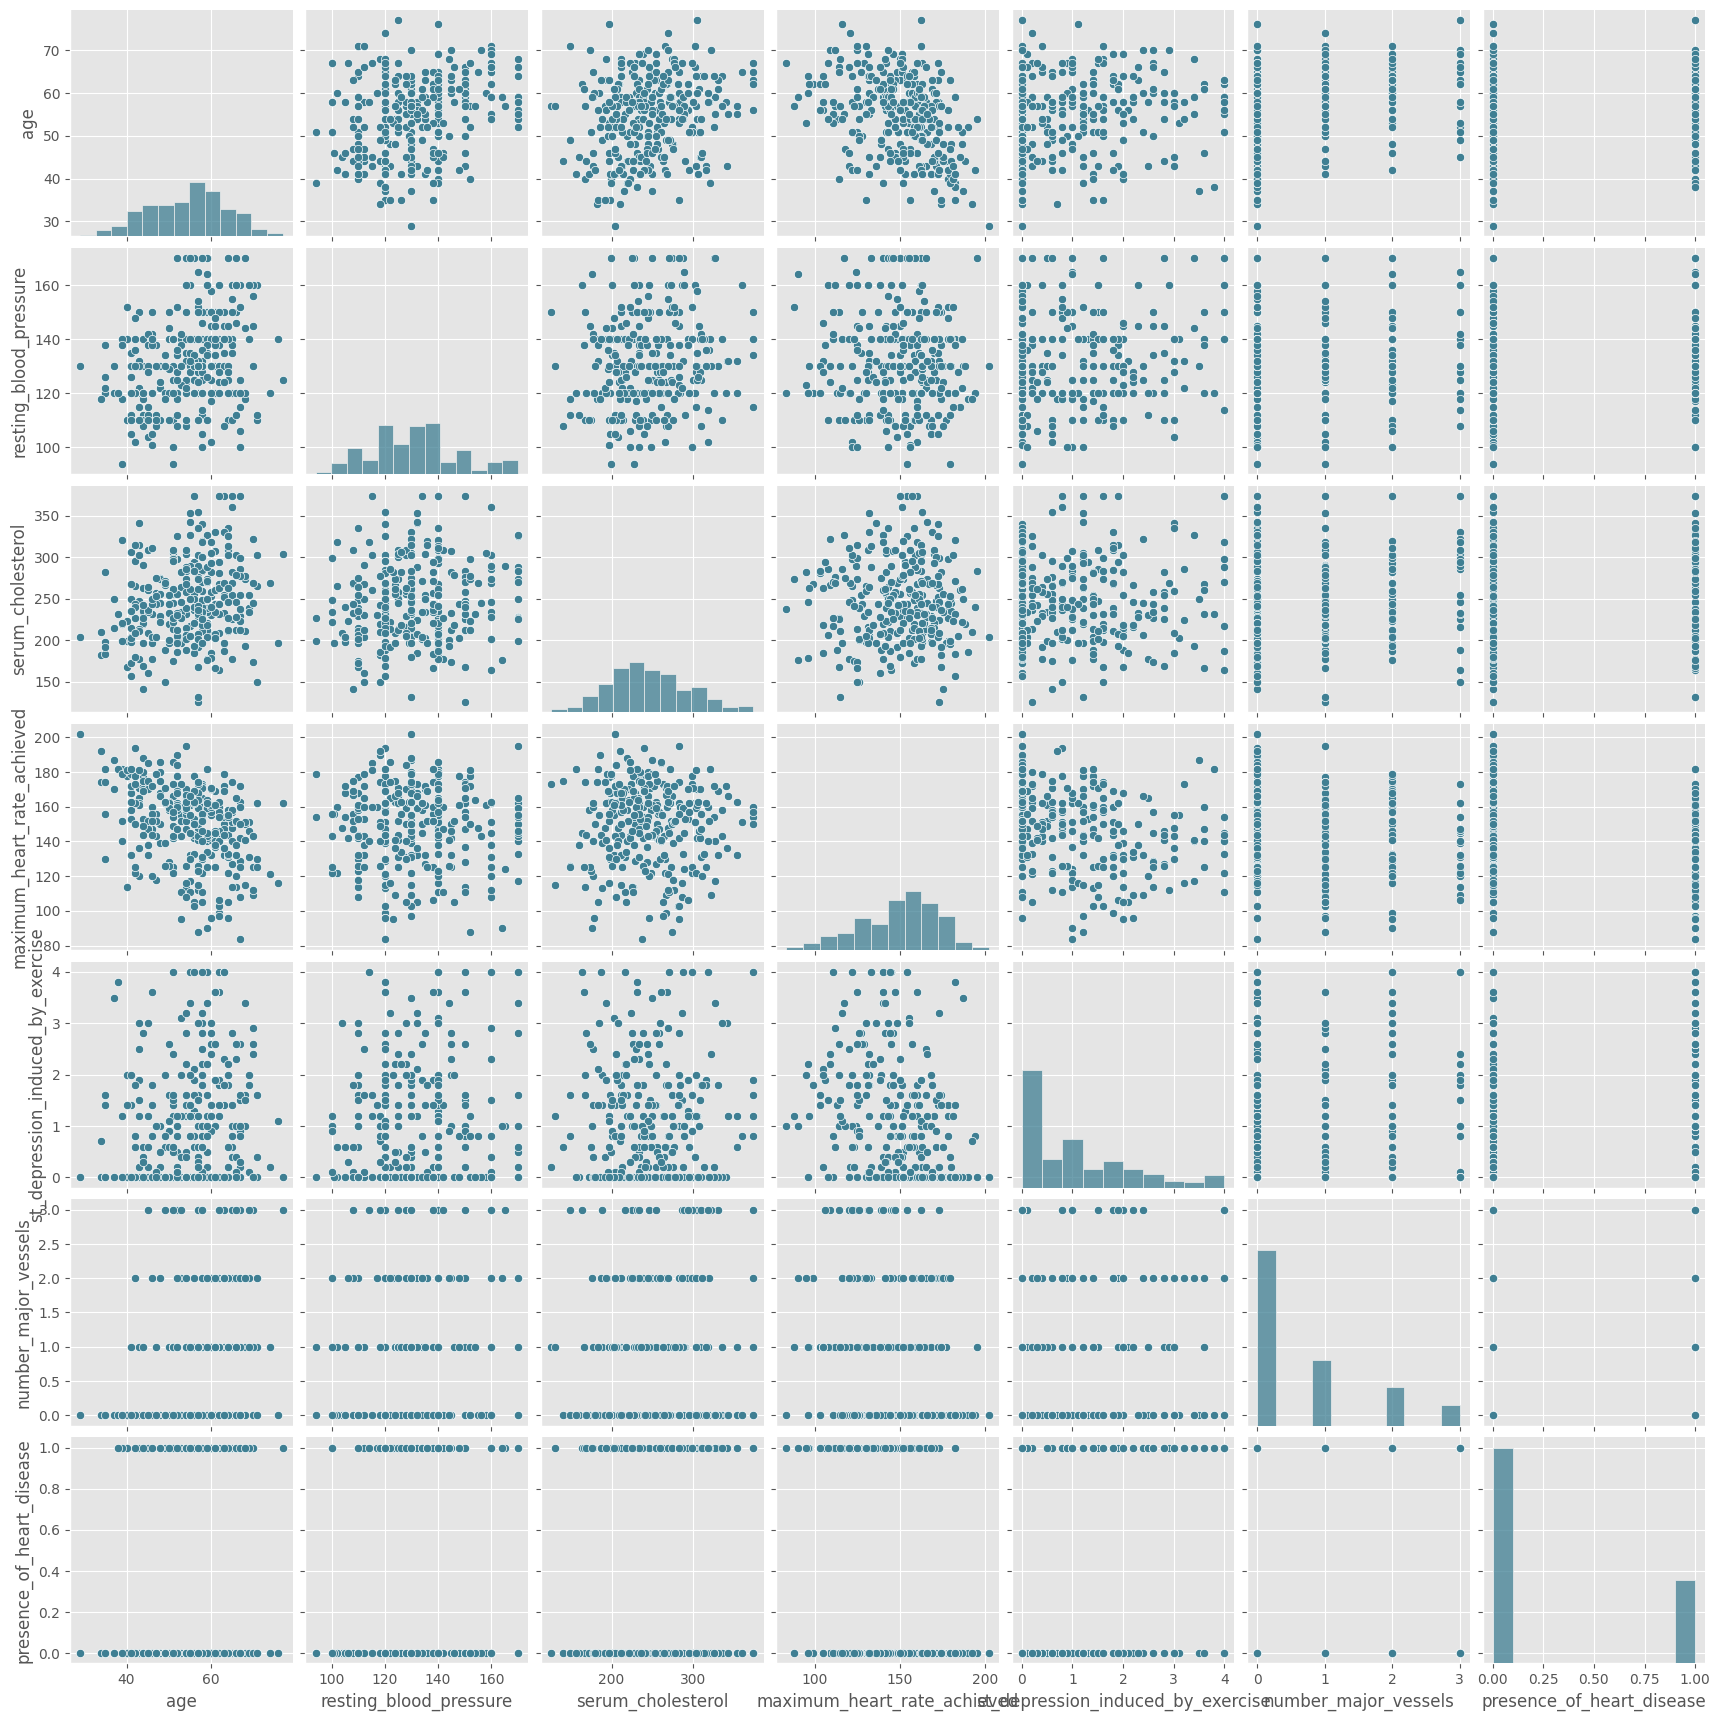

In [197]:
plt.figure(figsize=(25, 15))
sns.pairplot(data=df[numeric_cols])
plt.show()


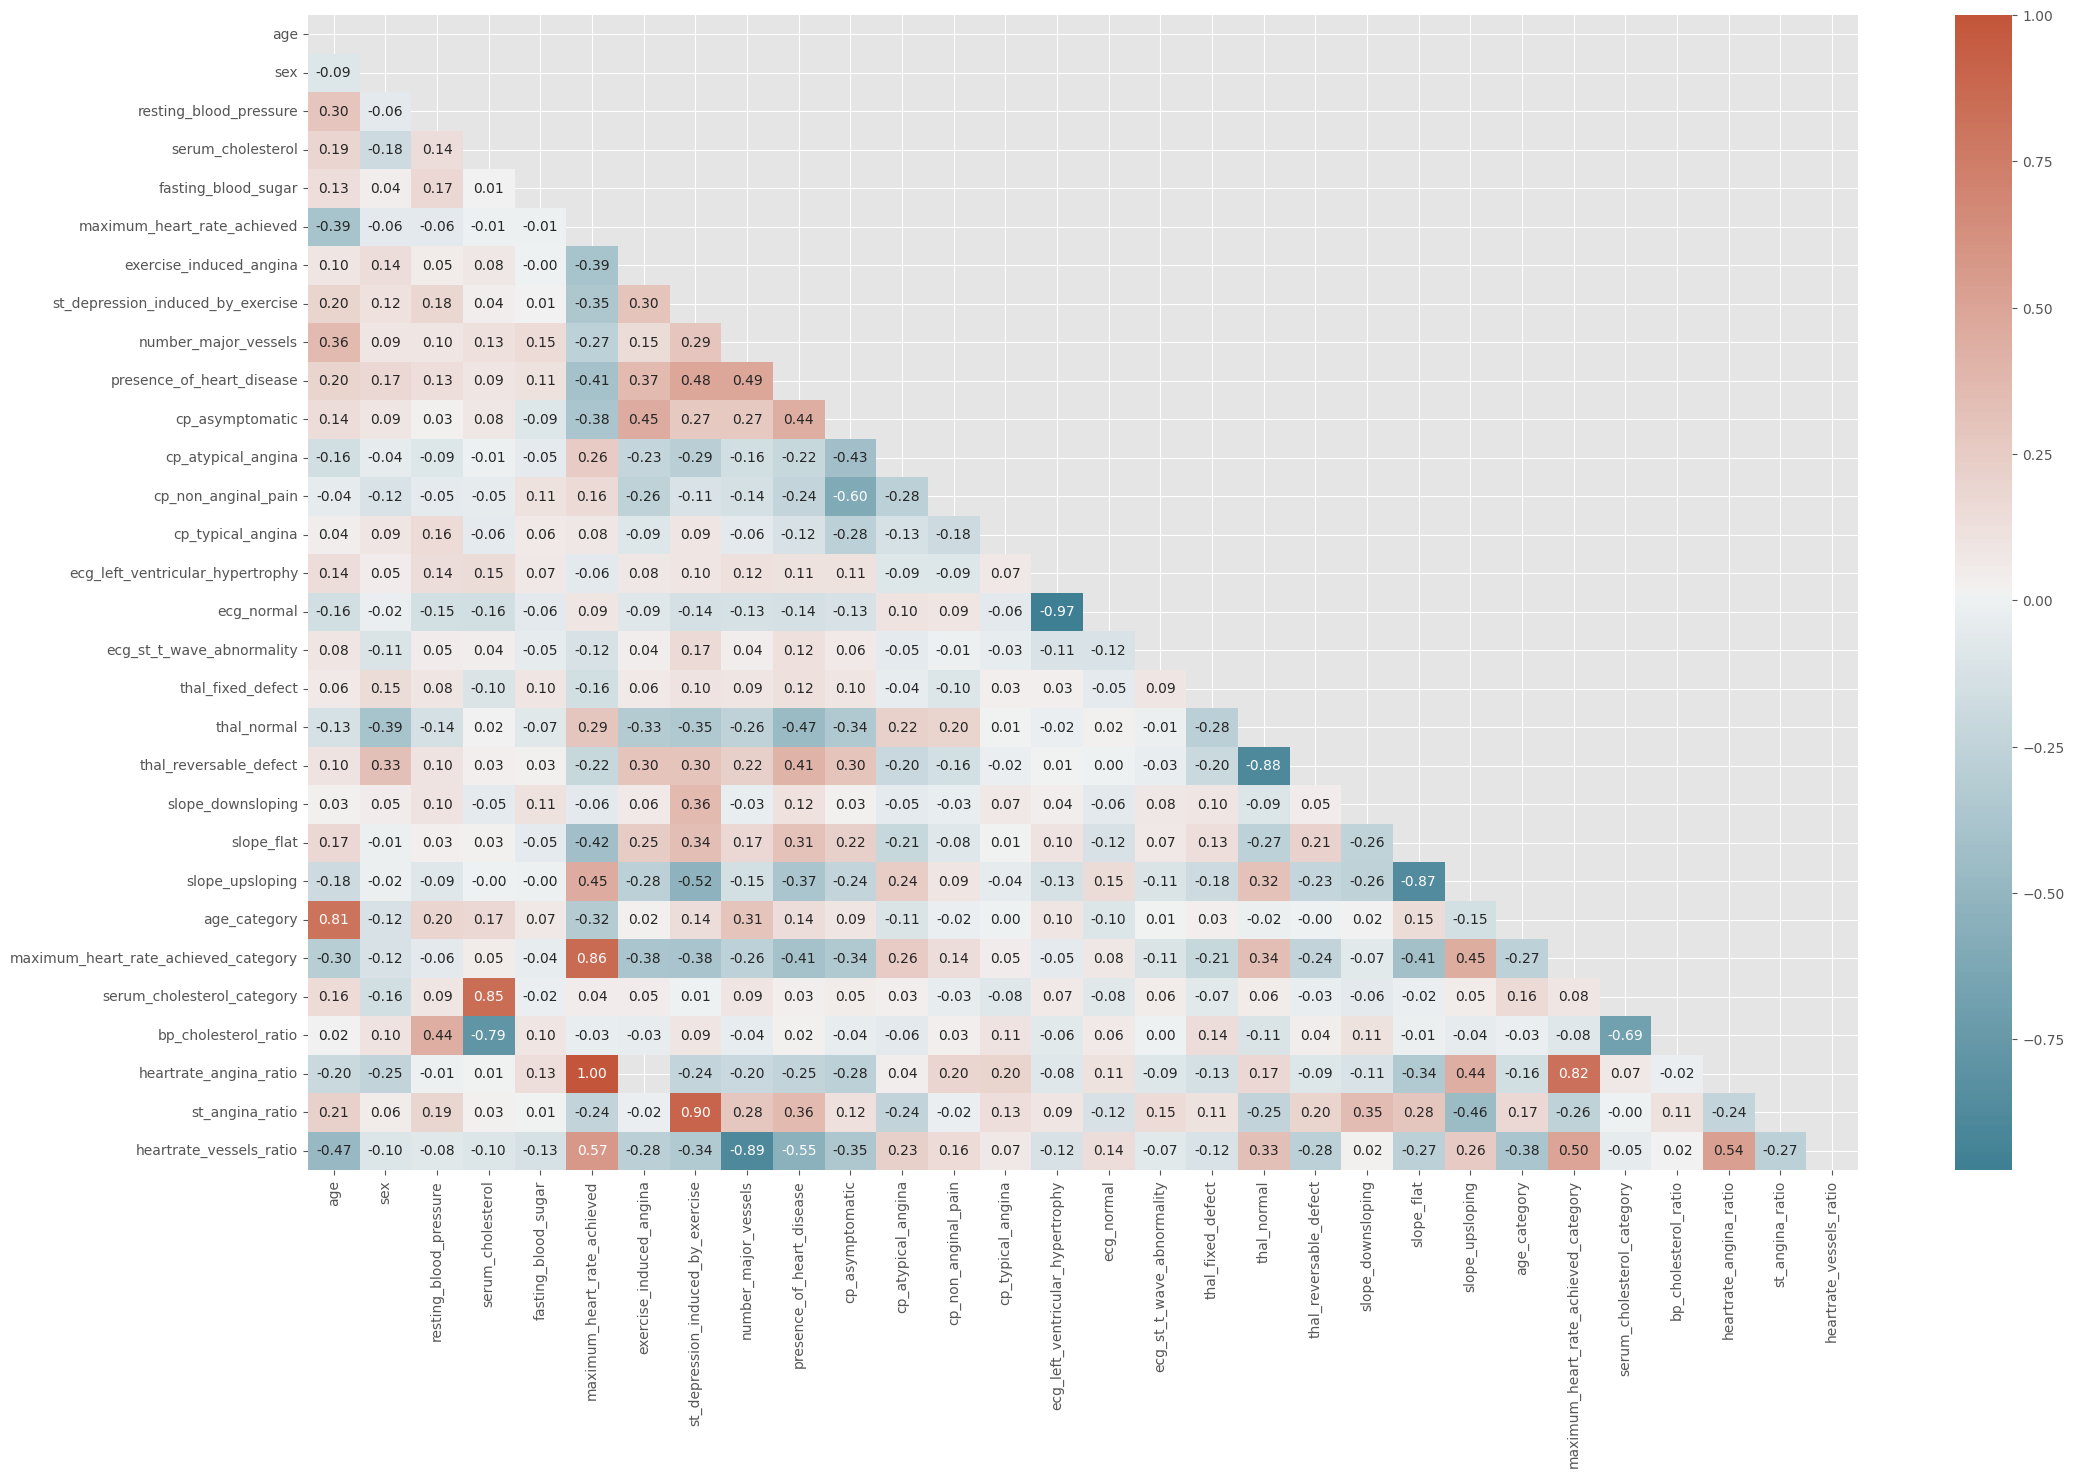

In [198]:
plt.figure(figsize=(25, 15))
num_variables = df.select_dtypes(include=["float64","int64", "bool"])
corr_df = num_variables.corr()
mask = np.triu(np.ones_like(corr_df, dtype=bool))
tri_df = corr_df.mask(mask)
cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(tri_df,annot=True,fmt=".2f",cmap = cmap)
plt.show()

Heatmap Review and Detection of Correlated Variables

Upon examining the heatmap, correlations are clearly visible through colors. Reds represent positive correlations, while blues indicate negative correlations.

Variables with correlations greater than 0.70 can cause multicollinearity problems. Therefore, it is generally advisable to remove one of the correlated variables.

Highly correlated variables convey the same information, and their small differences can mislead machine learning models. Removing these variables can improve model performance.
Newly added features show high correlation, and to assess their impact, a threshold of 0.85 has been set.
Some of these variables include:

ecg_normal and ecg_left_ventricular_hypertrophy: A very high negative correlation of -0.97.
thal_normal and thal_reversible_defect: A very high negative correlation of -0.88.
slope_flat and slope_upsloping: A very high negative correlation of -0.87.
A function has been written for this process. The goal is to remove one of the highly correlated features above the threshold.

In [199]:
def correlation_analysis(df: pd.DataFrame, threshold: float = 0.85) -> pd.DataFrame:
    """
    Analyzes and removes highly correlated features from the dataset.

    """
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    df.drop(columns=to_drop, axis=1, inplace=True)
    print(f"Features removed from the dataset: {to_drop}")
    return df

In [200]:
print(f"Number of features before removing correlated features: {len(df.columns)}")
df = correlation_analysis(df)
print(f"Number of features after removing correlated features: {len(df.columns)}")

Number of features before removing correlated features: 30
Features removed from the dataset: ['ecg_normal', 'thal_reversable_defect', 'slope_upsloping', 'maximum_heart_rate_achieved_category', 'heartrate_angina_ratio', 'st_angina_ratio', 'heartrate_vessels_ratio']
Number of features after removing correlated features: 23


Number of features before removing correlated features: 30
Features removed from the dataset: ['ecg_normal', 'thal_reversable_defect', 'slope_upsloping', 'maximum_heart_rate_achieved_category', 'heartrate_angina_ratio', 'st_angina_ratio', 'heartrate_vessels_ratio']

Number of features after removing correlated features: 23
New Features Added After Correlation Analysis:

The features age_category, serum_cholesterol_category, and bp_cholesterol_ratio have been added to the dataset following the correlation analysis.

Correlation Analysis Between Target Variable (presence_of_heart_disease) and Other Features

The correlation between the target variable presence_of_heart_disease and other numerical features has been analyzed. A threshold of 0.05 was set for the correlation, and the results were visualized.

Initially, highly correlated features were removed, and the exact number of features correlated with the target variable was determined.

A total of 18 features with a correlation higher than 0.05 with the target variable have been identified.

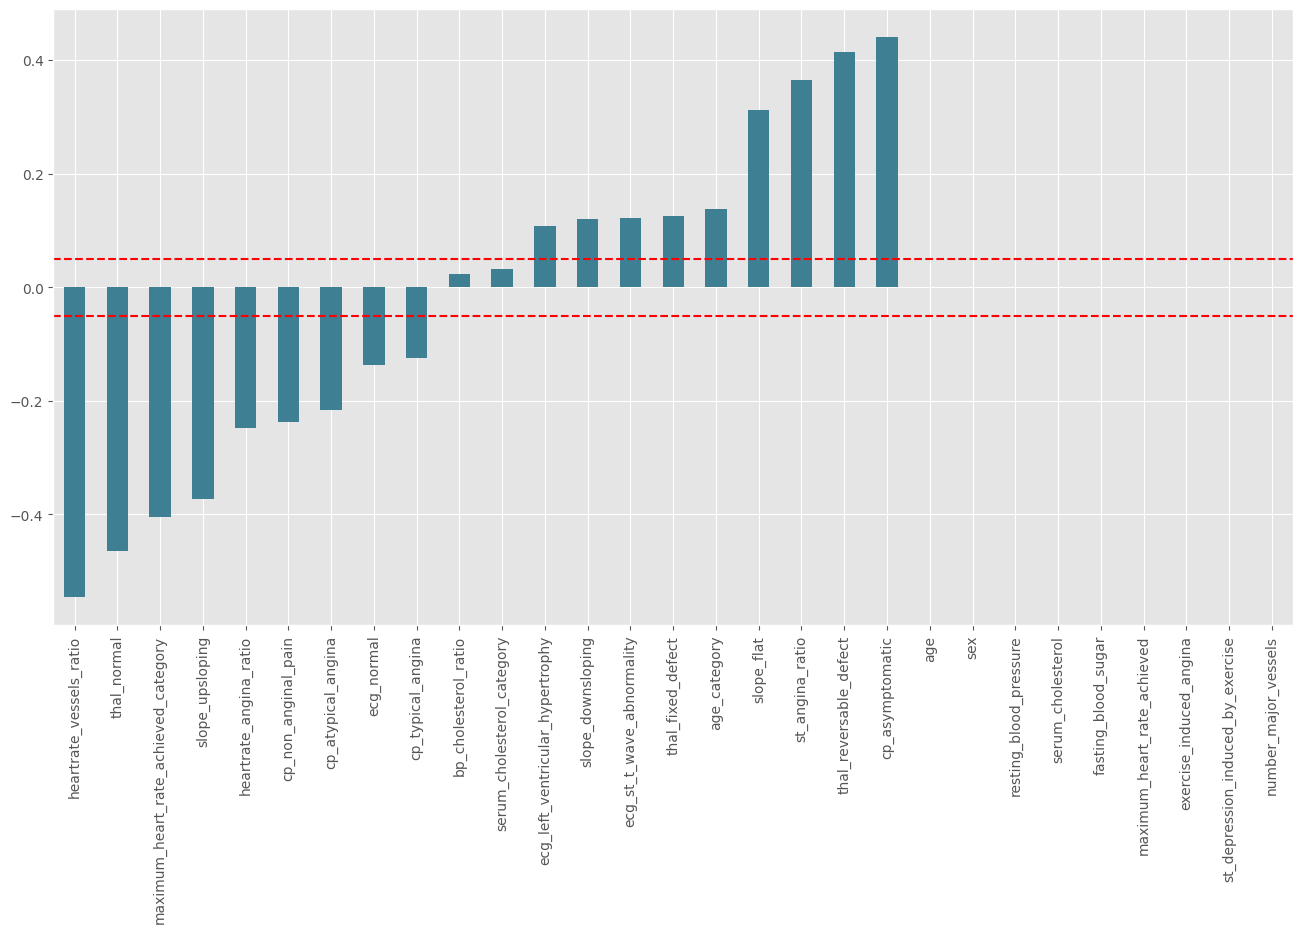

In [201]:
plt.figure(figsize=(16, 8))
tri_df["presence_of_heart_disease"].drop("presence_of_heart_disease").sort_values().plot(kind="bar")
plt.axhline(0.05, color ="red",linestyle ='--')
plt.axhline(-0.05, color='red',linestyle='--')
plt.show()

In [202]:
cor_target = abs(tri_df["presence_of_heart_disease"])
cor_target.drop("presence_of_heart_disease",inplace=True,axis=0)
correlated_features  = cor_target[cor_target >=0.05]
print("Total number of features:",len(df.select_dtypes(include=["float64","int64","int32"]).columns))
print("Number of correlated features:",len(correlated_features))

Total number of features: 23
Number of correlated features: 18


### Model Building and Evaluation¶
### In this section, the necessary scaling, normalization, and sampling processes will be applied at the relevant stages of the project.
### Selection of Models

### The task of predicting whether a person has heart disease or not is a binary classification problem in machine learning.

### Occam's Razor: Following the principle of moving from simple to complex models, the Logistic Regression model was initially used. Since strong linear correlations exist in the dataset, this model might perform well. Logistic regression can also be thought of as a simple neural network with one neuron. The binary cross-entropy function is used as the loss function to update the coefficients.
### Random Forest Classifier: A tree-based model was preferred as a second model. Between tree-based models, Random Forest Classifier was chosen. The reason is that boosting algorithms (e.g., XGBoost) perform better on high-dimensional datasets, but since the dataset in this project is very small, the risk of overfitting increases. Therefore, Random Forest Classifier was chosen as the comparison model.

### Another reason for selecting a tree-based model is that it can address the class imbalance issue and perform well on imbalanced datasets. Additionally, Random Forest Classifier is based on the principle of crowd wisdom, where the final decision is made by many independent weak trees, rather than a single decision tree. Tree-based models are also resistant to scaling issues, meaning they can be used without requiring dataset scaling.

### Both models handle class imbalances through the class_weights parameter, giving more importance to the low-density classes.

Selection of Evaluation Metrics

Two key metrics were selected for the initial evaluation.

Precision:
**bold text**
Definition: The ratio of true positive predictions to the total number of positive predictions (true positives + false positives).
Formula:

**Precision = TP / TP + FP**


Meaning: It shows how many of the patients classified as positive (heart disease) by the model actually have heart disease.
If false positives (healthy individuals misclassified as having heart disease) could lead to serious consequences, precision may be more important. For example, to avoid unnecessary treatment or concern for patients, reducing false positives becomes crucial.

**Recall:**


Definition: The ratio of true positives (those with heart disease) to the total number of positive cases (true positives + false negatives).
Formula:

**Recall = TP / TP + FN**

Meaning: It shows how many of the actual heart disease patients were correctly identified.
If false negatives (heart disease patients misclassified as healthy) carry a greater risk, recall becomes more important. For example, failing to detect a heart disease patient could lead to life-threatening situations.

Since it is crucial that heart disease patients are not misclassified as healthy, RECALL was chosen as the first evaluation metric.

The second metric chosen is ROC AUC score. The ROC AUC score evaluates the model's ability to distinguish between all classes (both positive and negative). It focuses on balancing false positives and false negatives (sensitivity and specificity).

Defining the Model Evaluation Function

The entire model training and evaluation process has been encapsulated in a function to make it easier and error-free. This function takes the model, the split data, the cross-validation function, and the score function as parameters, and returns the trained model, a dataframe containing the training and validation scores, the final test score, and predictions on the test set. If the plot parameter is set to True, it will plot the training and validation results. Applying cross-validation on training data is a commonly preferred method during model evaluation. By doing this, the results on the training, validation, and test sets can be compared, making it easier to observe overfitting and underfitting situations, and hyperparameters can be adjusted based on these results. Additionally, if the problem is a classification task, the function will also print the confusion matrix. The confusion matrix in sklearn shows the true negatives, false positives in the first row, and false negatives, true positives in the second row.

In [203]:
def train_and_evaluate_model(
    model: BaseEstimator,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    score_func: Callable[[np.ndarray, np.ndarray], float],
    cv_type: BaseCrossValidator,
    plot: bool = True
) -> Tuple[BaseEstimator, float, pd.DataFrame, Union[np.ndarray, pd.Series]]:
    """
    Trains and evaluates a machine learning model using cross-validation.

    """
    # Initialize score lists
    train_scores = []
    validation_scores = []
    score_per_fold = []
    fold = 1

    # Cross-validation loop
    for train_index, test_index in cv_type.split(X_train, y_train):
        X_train_cv, X_validation_cv = X_train.iloc[train_index], X_train.iloc[test_index]
        y_train_cv, y_validation_cv = y_train.iloc[train_index], y_train.iloc[test_index]

        # Fit model on training fold
        model.fit(X_train_cv, y_train_cv)
        y_pred_train = model.predict(X_train_cv)
        y_pred_validation = model.predict(X_validation_cv)

        # Compute scores
        train_score = score_func(y_train_cv, y_pred_train)
        validation_score = score_func(y_validation_cv, y_pred_validation)

        # Append scores
        train_scores.append(train_score)
        validation_scores.append(validation_score)

        # Print fold scores
        print(f'Fold {fold} training_{score_func.__name__}: {train_score:.2f}')
        print(f'Fold {fold} validation_{score_func.__name__}: {validation_score:.2f}')

        fold += 1
        score_per_fold.append(fold)

    print("Cross-validation phase completed! Starting model training...")

    # Train on the entire training set
    model.fit(X_train, y_train)
    print("*******************************************")
    print("Model training completed!")
    print("*******************************************")

    # Predict on the test set
    if score_func.__name__ == "roc_auc_score":
        y_pred_test = model.predict_proba(X_test)[:, 1]
    else:
        y_pred_test = model.predict(X_test)

    # Final test score
    final_test_score = score_func(y_test, y_pred_test)

    # Create scores dictionary
    scores_dict = {
        "fold": range(1, len(score_per_fold) + 1),
        f"training_{score_func.__name__}": train_scores,
        f"validation_{score_func.__name__}": validation_scores
    }

    # Create scores DataFrame
    scores_df = pd.DataFrame(scores_dict)

    # Calculate percentage differences
    percentage_difference_train_valid = ((np.mean(validation_scores) - np.mean(train_scores)) / np.mean(train_scores)) * 100
    percentage_difference_train_test = ((final_test_score - np.mean(train_scores)) / np.mean(train_scores)) * 100

    # Print summary
    print(f"Average training_{score_func.__name__} score: {np.mean(train_scores):.2f}")
    print(f"Average validation_{score_func.__name__} score: {np.mean(validation_scores):.2f}")
    print(f"Final test_{score_func.__name__} score: {final_test_score:.2f}")
    print(f"Percentage difference between validation and training scores: %{percentage_difference_train_valid:.2f}")
    print(f"Percentage difference between final score and training score: %{percentage_difference_train_test:.2f}")

    # Print confusion matrix for classification problems
    if score_func.__name__ in ["precision_score", "recall_score", "f1_score"]:
        cf_matrix = confusion_matrix(y_test, y_pred_test)
        print(f"Confusion matrix for the final test set:\n {cf_matrix}")

    print("*******************************************")

    # Plot scores if required
    if plot:
        sns.lineplot(data=scores_df, x="fold", y=f"training_{score_func.__name__}", marker="o", label=f"training_{score_func.__name__}")
        sns.lineplot(data=scores_df, x="fold", y=f"validation_{score_func.__name__}", marker="v", label=f"validation_{score_func.__name__}")
        plt.xlabel("Fold")
        plt.ylabel(f"{score_func.__name__}")
        plt.title(f"Scores per fold for {score_func.__name__}")
        plt.legend()
        plt.show()

    return model, final_test_score, scores_df, y_pred_test

**Defining the ROC Curve Function**

The ROC curve graphically represents the performance of a binary classification model at different threshold values. This curve plots the True Positive Rate (TPR) against the False Positive Rate (FPR). TPR measures how accurately the model identifies true positive cases, while FPR measures the rate at which the model incorrectly classifies negative cases as positive. The ROC curve visualizes the balance between TPR and FPR as the classifier's decision threshold changes. The Area Under the Curve (AUC) represents the area under the curve and is used to measure the overall performance of the model. Therefore, the ROC curve and AUC are crucial tools for evaluating and comparing the performance of binary classification models.

In [204]:
def plot_roc_curve(y_true: np.ndarray, y_pred_prob: np.ndarray) -> None:
    """
    Computes and plots the Receiver Operating Characteristic (ROC) curve and calculates the Area Under Curve (AUC).
    """
    # Compute ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)

    # Compute Area Under Curve (AUC)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.figure()
    plt.plot(fpr, tpr, color="teal", lw=2, label="ROC curve (area = %0.2f)" % roc_auc)
    plt.plot([0, 1], [0, 1], color="lightsteelblue", lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver Operating Characteristic (ROC) Curve")
    plt.legend(loc="lower right")
    plt.show()

In [205]:
df.head()

,age,sex,resting_blood_pressure,serum_cholesterol,fasting_blood_sugar,maximum_heart_rate_achieved,exercise_induced_angina,st_depression_induced_by_exercise,number_major_vessels,presence_of_heart_disease,cp_asymptomatic,cp_atypical_angina,cp_non_anginal_pain,cp_typical_angina,ecg_left_ventricular_hypertrophy,ecg_st_t_wave_abnormality,thal_fixed_defect,thal_normal,slope_downsloping,slope_flat,age_category,serum_cholesterol_category,bp_cholesterol_ratio
0,63.0,1,145,233.0,1,150.0,0,2.3,0.0,0,0,0,0,1,1,0,1,0,1,0,3.0,2.0,0.622318
1,67.0,1,160,286.0,0,108.0,1,1.5,3.0,1,1,0,0,0,1,0,0,1,0,1,3.0,2.0,0.559441
2,67.0,1,120,229.0,0,129.0,1,2.6,2.0,0,1,0,0,0,1,0,0,0,0,1,3.0,2.0,0.524017
3,37.0,1,130,250.0,0,187.0,0,3.5,0.0,0,0,0,1,0,0,0,0,1,1,0,1.0,2.0,0.520000
4,41.0,0,130,204.0,0,172.0,0,1.4,0.0,0,0,1,0,0,1,0,0,1,0,0,2.0,2.0,0.637255


**Splitting the Dataset into Training and Test Sets and Applying SMOTE Oversampling**

The target variable, presence_of_heart_disease, exhibits class imbalance in the dataset.

Four methods have been applied to address class imbalance:

1. **Stratify Parameter in Splitting:** The stratify parameter has been used in the train_test_split function to ensure the class distribution is maintained in both the training and testing sets.

2. **Class Weight in Models:** The class_weight parameter has been set to balanced in the models to give more importance to the minority class.

3. **SMOTE Oversampling:** The widely used SMOTE (Synthetic Minority Over-sampling Technique) method has been applied to balance the class distribution by generating synthetic samples for the minority class.

4. **Stratified Cross-Validation:** The StratifiedKFold cross-validation method has been used to ensure that each fold of the cross-validation maintains the same class distribution as the original dataset.

In [206]:
describe_categorical_feature(df, "presence_of_heart_disease")

Data type: int64


,presence_of_heart_disease,count
0,0,214
1,1,83


In [207]:
describe_feature(df, "presence_of_heart_disease")

Data type: int64


,count,mean,std,min,25%,50%,75%,max
presence_of_heart_disease,297.0,0.279461,0.449492,0.0,0.0,0.0,1.0,1.0


# **Sampling**
### **SMOTE (Synthetic Minority Over-sampling Technique)**

SMOTE is an over-sampling technique used to increase the number of minority class samples in imbalanced datasets. It generates synthetic samples by using the differences between existing minority class samples, thus reducing the class imbalance.

**How it works:**

1. **K-Nearest Neighbors:** For each minority class sample, the k nearest neighbors are identified.

2. **Generating New Samples:** A random neighbor is chosen, and a new sample is created along the vector between the current sample and its neighbor.

3. **Oversampling:** This process is repeated, and new synthetic minority class samples are added to the dataset.

**Advantages:**


*   **Balancing Imbalanced Data:** By increasing the minority class samples, SMOTE reduces the class imbalance in the dataset.
*   **Reducing Overfitting:** Instead of merely duplicating existing examples, SMOTE generates new synthetic examples, which helps in reducing the risk of overfitting.



### **SMOTE helps the model learn the minority class better by increasing the number of minority class examples in the training set. However, the test set should remain untouched as it is used to evaluate the model's performance. The test set should be kept separate from the training process and reflect real-world performance.**

**Feature Selection and Data Splitting**

1. One of the key adjustments in data splitting is choosing the test size.

2. For the test size selection, values of 10%, 12%, 15%, 20%, and 25% were tested in the model evaluation function. Based on the training, validation, and final scores, the optimal test size was determined to be 12% (training recall = 0.88, validation recall = 0.89, test recall = 0.90 - scaled).

In [208]:
target = "presence_of_heart_disease"
columns_that_will_not_used = ["presence_of_heart_disease"]
features = [col for col in df.columns if col not in columns_that_will_not_used]
X = df[features]
y= df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.12, stratify=y, random_state=42)

In [209]:
print(X_train.shape)
print(y_train.shape)
y_train.value_counts(normalize=True) * 100

(261, 22)
(261,)


,proportion
presence_of_heart_disease,
0,72.030651
1,27.969349


In [210]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

As a result of the SMOTE operation, the number of rows in X_train increased from 261 to 376, with synthetic data being generated.
Prior to the SMOTE operation, the distribution was 72% for class 0 and 28% for class 1. After applying SMOTE, the distribution became 50% for both classes.
The SMOTE operation was only applied to the training set.

In [211]:
print(X_train_smote.shape)
print(X_test.shape)
print(y_train_smote.shape)
print(y_test.shape)
y_train_smote.value_counts(normalize=True) * 100

(376, 22)
(36, 22)
(376,)
(36,)


,proportion
presence_of_heart_disease,
0,50.0
1,50.0


### Logistic Regression Model

Highly skewed data should be scaled for the model to perform better. For this, StandardScaler is used within the pipeline.

Since the dataset is not very large, GridSearchCV is employed to achieve the most accurate result for hyperparameter tuning. As a result, the regularization parameter C is set to 0.005, and the penalty is set to l2 (ridge). Since there is a class imbalance in the target variable, the class_weight="balanced" option is preferred to give more importance to the less represented class.

1. C: The regularization parameter in Logistic Regression. Smaller values indicate stronger regularization and reduce the impact of individual data points on the model.

2. Penalty: The type of regularization penalty used in Logistic Regression. "l2" refers to Ridge regularization, which penalizes the square of the coefficients and encourages smaller coefficient values.
StratifiedKFold is chosen for cross-validation to address the class imbalance.

Logistic Regression Hyperparameter Tuning


*   Since the dataset is small, GridSearch is used for hyperparameter tuning, which tries all combinations using a brute-force method.
*   When the dataset size and the number of parameters increase, this method may become impractical due to long processing times. In such cases, Random Search or Bayesian optimization algorithms can be used.


In [212]:
skf = StratifiedKFold(n_splits=10,shuffle=True,random_state=42)
scoring = make_scorer(recall_score)
lr_cv = LogisticRegression()

lr_pipeline_cv = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", lr_cv)
])

params_lr = {
    "classifier__penalty": ["l1", "l2","elasticnet"],
    "classifier__C": [0.0001, 0.001, 0.005, 0.006, 0.007, 0.008, 0.009, 0.01, 0.02, 0.03, 0.04, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 10, 100, 200],
    "classifier__class_weight": ["balanced"]
}

with mlflow.start_run(run_name="GridSearchCV Logistic Regression"):

    grid_rf = GridSearchCV(estimator=lr_pipeline_cv,param_grid=params_lr,cv=skf,scoring=scoring,verbose=1,n_jobs=1)
    grid_rf.fit(X,y)
    best_hyperparams_lr = grid_rf.best_params_
    best_score_lr = grid_rf.best_score_
    print("Best hyperparameters of Logistic Regression:", best_hyperparams_lr)
    print("Best score of Logistic Regression:", best_score_lr)

    mlflow.log_params(best_hyperparams_lr)
    mlflow.log_metric("lr_best_recall_score", best_score_lr)

Fitting 10 folds for each of 72 candidates, totalling 720 fits
Best hyperparameters of Logistic Regression: {'classifier__C': 0.005, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2'}
Best score of Logistic Regression: 0.8680555555555556


### Example Usage of `train_and_evaluate_model` with Logistic Regression

Here, we will create a `LogisticRegression` model within a `Pipeline` to include `StandardScaler` for preprocessing. Then, we will call the `train_and_evaluate_model` function using the SMOTE-resampled training data and the original test data, evaluating based on `recall_score` and `StratifiedKFold`.

Fold 1 training_recall_score: 0.80
Fold 1 validation_recall_score: 0.62
Fold 2 training_recall_score: 0.80
Fold 2 validation_recall_score: 0.71
Fold 3 training_recall_score: 0.80
Fold 3 validation_recall_score: 0.71
Fold 4 training_recall_score: 0.79
Fold 4 validation_recall_score: 0.86
Fold 5 training_recall_score: 0.77
Fold 5 validation_recall_score: 0.86
Fold 6 training_recall_score: 0.77
Fold 6 validation_recall_score: 1.00
Fold 7 training_recall_score: 0.77
Fold 7 validation_recall_score: 0.71
Fold 8 training_recall_score: 0.82
Fold 8 validation_recall_score: 0.71
Fold 9 training_recall_score: 0.78
Fold 9 validation_recall_score: 0.88
Fold 10 training_recall_score: 0.80
Fold 10 validation_recall_score: 0.75
Cross-validation phase completed! Starting model training...
*******************************************
Model training completed!
*******************************************
Average training_recall_score score: 0.79
Average validation_recall_score score: 0.78
Final test_recall

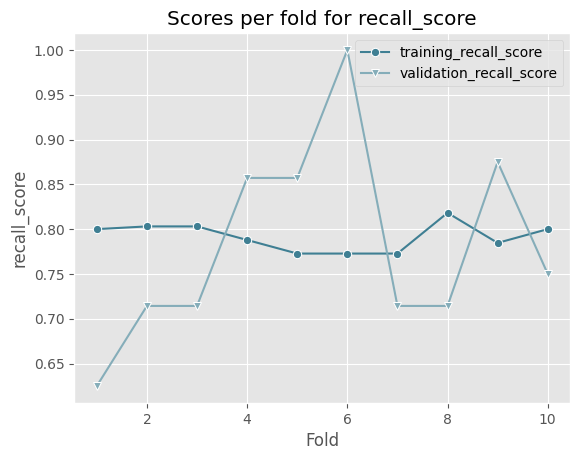

2026/06/28 13:44:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Registered model 'logistic_regression_not_scaled_model' already exists. Creating a new version of this model...
2026/06/28 13:44:59 WARNING mlflow.tracking._model_registry.fluent: Run with id e7727273679840e49f748fc3a92180a7 has no artifacts at artifact path 'logistic_regression_not_scaled_model', registering model based on models:/m-1e020da4facb4c38b3333c32cece7b41 instead
Created version '2' of model 'logistic_regression_not_scaled_model'.


In [213]:
best_hyperparams_lr =  {'C': 0.005, 'class_weight': 'balanced', 'penalty': 'l2'}

lr = LogisticRegression(**best_hyperparams_lr, random_state=22)
with mlflow.start_run(run_name="Logistic Regression Not Scaled Model: Metric = recall"):
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    lr_model, lr_final_test_recall_score, lr_recall_scores_df, lr_y_pred_test = train_and_evaluate_model(lr, X_train, y_train, X_test, y_test, recall_score, skf, plot=True)

    # Log model metrics
    mlflow.log_params(best_hyperparams_lr)
    mlflow.log_metric("final_test_recall_score", lr_final_test_recall_score)

    # Log the model
    model_path = "logistic_regression_not_scaled_model"
    mlflow.sklearn.log_model(lr, model_path)

    # Register the model in the Model Registry
    mlflow.register_model(model_uri=f"runs:/{mlflow.active_run().info.run_id}/{model_path}", name="logistic_regression_not_scaled_model")


    output_dir = "mlflow_model_csv_data"
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # Log artifacts
    lr_recall_scores_df.to_csv("mlflow_model_csv_data/lr_not_scaled_recall_scores.csv", index=False)
    mlflow.log_artifact("mlflow_model_csv_data/lr_not_scaled_recall_scores.csv")

Model Training and Evaluation with Scaling

* Average training_recall_score result: 0.88

* Average validation_recall_score result: 0.89
* Final test_recall_score result: 0.90
* Percentage difference between validation score and training score: +1.44%
* Percentage difference between final score and training score: +2.66%
* Confusion matrix created for the final test set:
* [[21 5] [ 1 9]]
* In the confusion matrix, only 1 person was classified * * as FN (false negative), while TP = 9 people were correctly classified as heart disease patients. The model has produced results suitable for the goal.
* The values mentioned above were created without adding new features to the data.
Evaluation Metric recall

Fold 1 training_recall_score: 0.93
Fold 1 validation_recall_score: 0.89
Fold 2 training_recall_score: 0.93
Fold 2 validation_recall_score: 0.95
Fold 3 training_recall_score: 0.93
Fold 3 validation_recall_score: 0.89
Fold 4 training_recall_score: 0.93
Fold 4 validation_recall_score: 0.84
Fold 5 training_recall_score: 0.93
Fold 5 validation_recall_score: 0.89
Fold 6 training_recall_score: 0.93
Fold 6 validation_recall_score: 0.79
Fold 7 training_recall_score: 0.94
Fold 7 validation_recall_score: 1.00
Fold 8 training_recall_score: 0.92
Fold 8 validation_recall_score: 0.83
Fold 9 training_recall_score: 0.93
Fold 9 validation_recall_score: 0.89
Fold 10 training_recall_score: 0.93
Fold 10 validation_recall_score: 0.95
Cross-validation phase completed! Starting model training...
*******************************************
Model training completed!
*******************************************
Average training_recall_score score: 0.93
Average validation_recall_score score: 0.89
Final test_recall

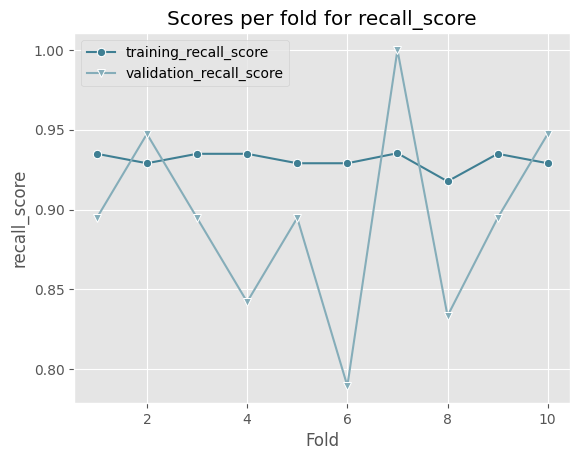

Final Logistic Regression Recall Score: 0.9


In [214]:
lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(class_weight='balanced', random_state=42))
])

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Call the train_and_evaluate_model function
model_lr, final_recall_lr, scores_df_lr, y_pred_test_lr = train_and_evaluate_model(
    model=lr_model,
    X_train=X_train_smote,
    y_train=y_train_smote,
    X_test=X_test,
    y_test=y_test,
    score_func=recall_score,
    cv_type=skf,
    plot=True
)

print("Final Logistic Regression Recall Score:", final_recall_lr)

Fold 1 training_roc_auc_score: 0.88
Fold 1 validation_roc_auc_score: 0.83
Fold 2 training_roc_auc_score: 0.84
Fold 2 validation_roc_auc_score: 0.92
Fold 3 training_roc_auc_score: 0.87
Fold 3 validation_roc_auc_score: 0.73
Fold 4 training_roc_auc_score: 0.86
Fold 4 validation_roc_auc_score: 0.88
Fold 5 training_roc_auc_score: 0.84
Fold 5 validation_roc_auc_score: 0.95
Fold 6 training_roc_auc_score: 0.85
Fold 6 validation_roc_auc_score: 0.88
Fold 7 training_roc_auc_score: 0.88
Fold 7 validation_roc_auc_score: 0.72
Fold 8 training_roc_auc_score: 0.86
Fold 8 validation_roc_auc_score: 0.88
Fold 9 training_roc_auc_score: 0.86
Fold 9 validation_roc_auc_score: 0.94
Fold 10 training_roc_auc_score: 0.85
Fold 10 validation_roc_auc_score: 0.88
Cross-validation phase completed! Starting model training...
*******************************************
Model training completed!
*******************************************
Average training_roc_auc_score score: 0.86
Average validation_roc_auc_score score: 

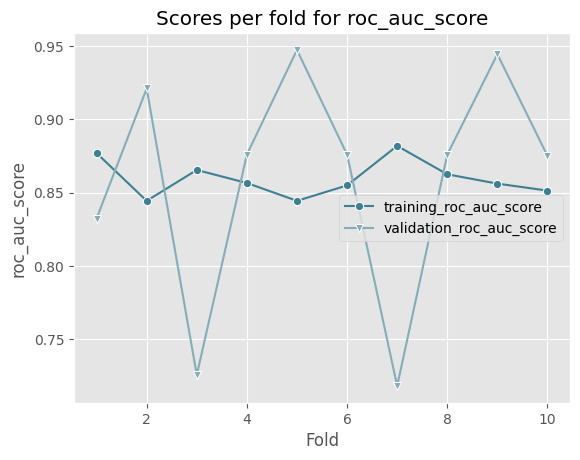

2026/06/28 13:45:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Registered model 'logistic_regression_scaled_model_roc_auc_score' already exists. Creating a new version of this model...
2026/06/28 13:45:12 WARNING mlflow.tracking._model_registry.fluent: Run with id 1b204a33b9a9410a9532fb9af4dd9e15 has no artifacts at artifact path 'logistic_regression_scaled_model_roc_auc_score', registering model based on models:/m-5ee5c59dcfda45ed977572dac8c82d54 instead
Created version '2' of model 'logistic_regression_scaled_model_roc_auc_score'.


In [215]:

# The best parameters found after grid search are added to the model.

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", lr)
])

with mlflow.start_run(run_name="Logistic Regression Scaled Model: Metric = roc_auc_score"):

    lr_model, lr_final_test_roc_auc_score, lr_roc_auc_score_df, lr_y_pred_test = train_and_evaluate_model(lr_pipeline, X_train, y_train, X_test, y_test, roc_auc_score, skf, plot=True)

    # Log model metrics
    mlflow.log_params(best_hyperparams_lr)
    mlflow.log_metric("final_test_roc_auc_score", lr_final_test_roc_auc_score)

    # Log the model
    model_path = "logistic_regression_scaled_model_roc_auc_score"
    mlflow.sklearn.log_model(lr_pipeline, model_path)

    # Register the model in the Model Registry
    mlflow.register_model(model_uri=f"runs:/{mlflow.active_run().info.run_id}/{model_path}", name="logistic_regression_scaled_model_roc_auc_score")

    # Log artifacts
    lr_roc_auc_score_df.to_csv("mlflow_model_csv_data/lr_scaled_roc_auc_scores.csv", index=False)
    mlflow.log_artifact("mlflow_model_csv_data/lr_scaled_roc_auc_scores.csv")

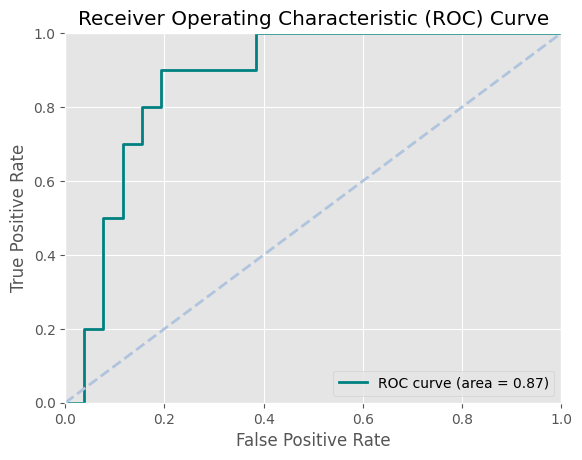

In [216]:
plot_roc_curve(y_test,lr_y_pred_test)

Logistic Regression Feature Importances Table

* The weightings of the model's features are shown in the table.
* The weightings of the model's features are shown in the table. High positive weights are given to the features exercise_induced_angina, number_major_vessels, and st_depression_induced_by_exercise.

* A high negative weight is assigned to the feature the normal.

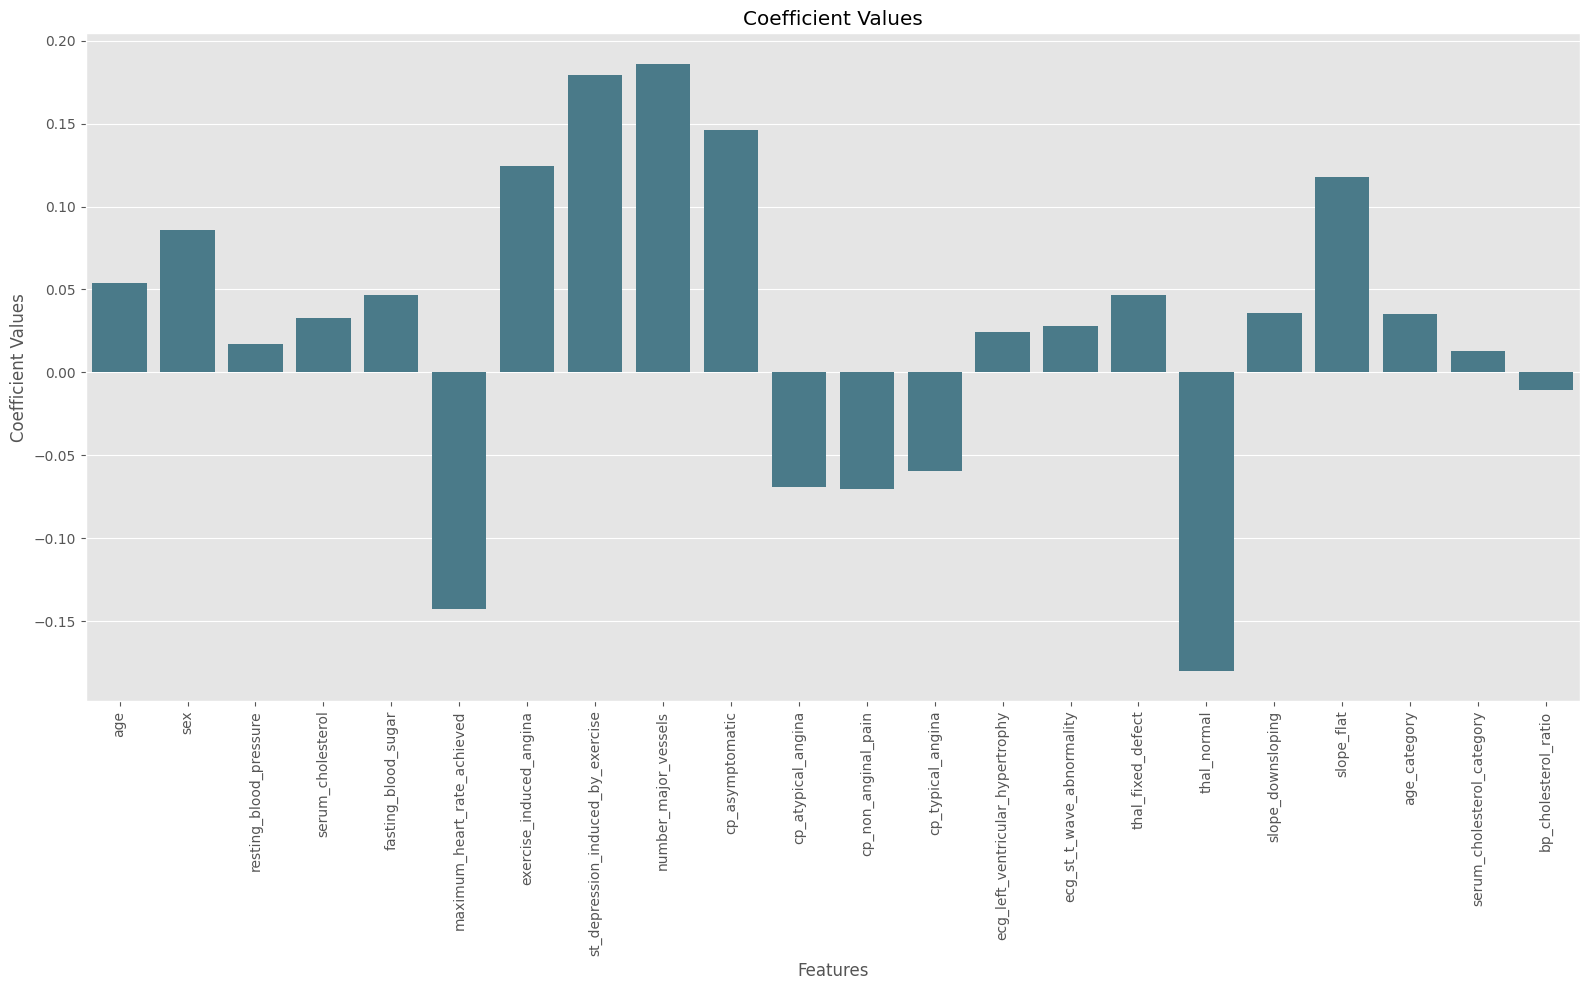

In [217]:
coef_values = lr_model.named_steps["classifier"].coef_[0]
columns = X_train.columns

plt.figure(figsize=(16, 10))
sns.barplot(x=columns, y=coef_values)
plt.xlabel("Features")
plt.ylabel("Coefficient Values")
plt.title("Coefficient Values")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Random Forest Classifier Model

Tree-based models are naturally capable of handling class imbalance and skewed features. They do not require scaling, but since scaling can still be useful, the model was scaled using StandardScaler.

The best parameters were determined using GridSearch:
* 'class_weight': 'balanced'
* 'max_depth': 2
* 'max_features': 0.5
* 'min_samples_leaf': 1
* 'min_samples_split': 2
* 'n_estimators': 200

### Explanation of Parameters:

* n_estimators: The number of decision trees in the forest. Increasing the number of trees makes the model more complex and increases training time. While this can improve performance, it also raises the risk of overfitting.

* max_depth: The maximum depth of each decision tree. Deeper trees allow for more complex models, but also increase the risk of overfitting.

* min_samples_split: The minimum number of samples required to split an internal node. Smaller values can lead to more trees and more complex models.

* min_samples_leaf: The minimum number of samples required in a leaf node. Smaller values lead to more complex models.

* max_features: The maximum number of features to consider when splitting a decision tree. Larger values increase the complexity of the model by allowing more features to be considered.

* class_weight: Used to handle class imbalances. The 'balanced' option assigns weights inversely proportional to class frequencies, which helps improve performance on imbalanced datasets.

### Random Forest Classifier Hyperparameter Tuning

* Due to the small size of the dataset, GridSearch was used for hyperparameter tuning. This method performs brute force by trying all possible combinations of the hyperparameters.

* When the dataset and the number of parameters increase, this method may become impractical due to long processing times. In such cases, alternative techniques like Random Search or Bayesian Optimization can be used to explore the hyperparameter space more efficiently.

* The hyperparameter tuning process took 1 hour.

In [218]:

# skf = StratifiedKFold(n_splits=10,shuffle=True,random_state=42)
# scoring = make_scorer(recall_score)
# rf_cv = RandomForestClassifier()

# rf_pipeline_cv = Pipeline([
#     ("scaler", StandardScaler()),
#     ("classifier", rf_cv)
# ])

# params_rf = {
#     "classifier__n_estimators": [ 100, 150, 200, 250, 300],
#     "classifier__max_depth": [None, 2, 4, 6, 8, 12],
#     "classifier__min_samples_split": [1, 2, 5, 10],
#     "classifier__min_samples_leaf": [1, 2, 4, 8],
#     "classifier__max_features": [0.3, 0.5, 0.7, 1],
#     "classifier__class_weight": ["balanced"]
# }

# with mlflow.start_run(run_name="RandomForestClassifier_Grid_Search"):

#     grid_rf = GridSearchCV(estimator=rf_pipeline_cv, param_grid=params_rf, cv=skf, scoring=scoring, verbose=1, n_jobs=1)
#     grid_rf.fit(X,y)
#     best_hyperparams_rf = grid_rf.best_params_
#     best_score_rf = grid_rf.best_score_
#     print("Best hyperparameters of RandomForestClassifier:", best_hyperparams_rf)
#     print("Best score(recall) of RandomForestClassifier:", best_score_rf)

#     mlflow.log_params(best_hyperparams_rf)
#     mlflow.log_metric("lr_best_recall_score", best_score_rf)

## Model Training and Evaluation

* Average Training Recall Score: 0.92
* Average Validation Recall Score: 0.86
* Final Test Recall Score: 0.90
* Difference in Validation Score vs. Training Score: -%5.87
* Difference in Final Score vs. Training Score: -%1.78

### Confusion Matrix for Final Test Set:

* [[21 5]
* [ 1 9]]

* Results: The confusion matrix of the Random Forest model gives the same results as the Logistic Regression model: TP = 9 (correctly classified heart disease patients), FN = 1 (false negative, incorrectly classified heart disease patient).

* Model Evaluation: In the Random Forest model, validation and test errors are lower than training errors, which may indicate underfitting in the model.

* Data Set: As the dataset contains very few examples, increasing the dataset size is required to improve the model's general performance.

* Note: The values presented here were generated without adding new features to the data.

## Evaluation Metric: recall_score

The non-scaled version of the model (RandomForestClassifier) will not be evaluated.

Fold 1 training_recall_score: 0.92
Fold 1 validation_recall_score: 1.00
Fold 2 training_recall_score: 0.92
Fold 2 validation_recall_score: 1.00
Fold 3 training_recall_score: 0.92
Fold 3 validation_recall_score: 1.00
Fold 4 training_recall_score: 0.92
Fold 4 validation_recall_score: 0.86
Fold 5 training_recall_score: 0.92
Fold 5 validation_recall_score: 0.71
Fold 6 training_recall_score: 0.92
Fold 6 validation_recall_score: 0.86
Fold 7 training_recall_score: 0.97
Fold 7 validation_recall_score: 0.71
Fold 8 training_recall_score: 0.94
Fold 8 validation_recall_score: 0.71
Fold 9 training_recall_score: 0.94
Fold 9 validation_recall_score: 0.88
Fold 10 training_recall_score: 0.92
Fold 10 validation_recall_score: 0.75
Cross-validation phase completed! Starting model training...
*******************************************
Model training completed!
*******************************************
Average training_recall_score score: 0.93
Average validation_recall_score score: 0.85
Final test_recall

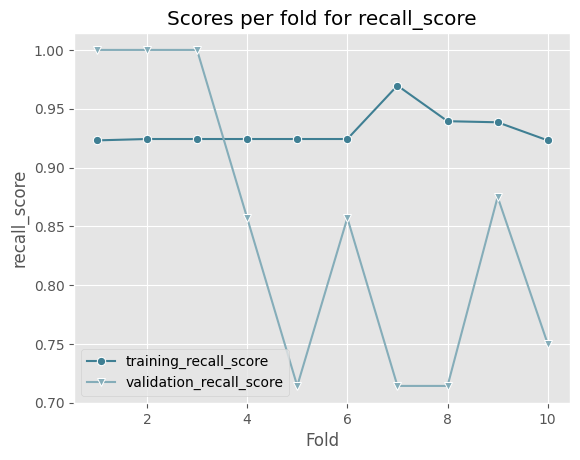

2026/06/28 13:45:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Registered model 'RandomForestClassifier_scaled_model_recall' already exists. Creating a new version of this model...
2026/06/28 13:45:30 WARNING mlflow.tracking._model_registry.fluent: Run with id a59dc767f39e48eda7cfc9a148e910ed has no artifacts at artifact path 'RandomForestClassifier_scaled_model_recall_score', registering model based on models:/m-af45741b24464cf08903d12d3ec9dd43 instead
Created version '2' of model 'RandomForestClassifier_scaled_model_recall'.


In [219]:
best_hyperparams_rf =  {'class_weight': 'balanced', 'max_depth': 2, 'max_features': 0.3, 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 200}
rf = RandomForestClassifier(**best_hyperparams_rf, random_state=22)

rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", rf)
])

with mlflow.start_run(run_name="RandomForestClassifier Scaled Model: Metric = recall"):
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    rf_model, rf_final_test_recall_score, rf_recall_scores_df, rf_y_pred_test = train_and_evaluate_model(rf_pipeline, X_train, y_train, X_test, y_test, recall_score, skf, plot=True)

    # Log model metrics
    mlflow.log_metric("RandomForestClassifier_final_test_recall_score", rf_final_test_recall_score)
    mlflow.log_params(best_hyperparams_rf)

    # Log the model
    model_path = "RandomForestClassifier_scaled_model_recall_score"
    mlflow.sklearn.log_model(rf_pipeline, model_path)

    # Register the model in the Model Registry
    mlflow.register_model(model_uri=f"runs:/{mlflow.active_run().info.run_id}/{model_path}", name="RandomForestClassifier_scaled_model_recall")

    # Log artifacts
    rf_recall_scores_df.to_csv("mlflow_model_csv_data/rf_scaled_recall_scores.csv", index=False)
    mlflow.log_artifact("mlflow_model_csv_data/rf_scaled_recall_scores.csv")

Fold 1 training_roc_auc_score: 0.88
Fold 1 validation_roc_auc_score: 0.87
Fold 2 training_roc_auc_score: 0.90
Fold 2 validation_roc_auc_score: 0.92
Fold 3 training_roc_auc_score: 0.91
Fold 3 validation_roc_auc_score: 0.89
Fold 4 training_roc_auc_score: 0.89
Fold 4 validation_roc_auc_score: 0.88
Fold 5 training_roc_auc_score: 0.88
Fold 5 validation_roc_auc_score: 0.83
Fold 6 training_roc_auc_score: 0.89
Fold 6 validation_roc_auc_score: 0.88
Fold 7 training_roc_auc_score: 0.93
Fold 7 validation_roc_auc_score: 0.65
Fold 8 training_roc_auc_score: 0.89
Fold 8 validation_roc_auc_score: 0.80
Fold 9 training_roc_auc_score: 0.90
Fold 9 validation_roc_auc_score: 0.88
Fold 10 training_roc_auc_score: 0.90
Fold 10 validation_roc_auc_score: 0.88
Cross-validation phase completed! Starting model training...
*******************************************
Model training completed!
*******************************************
Average training_roc_auc_score score: 0.90
Average validation_roc_auc_score score: 

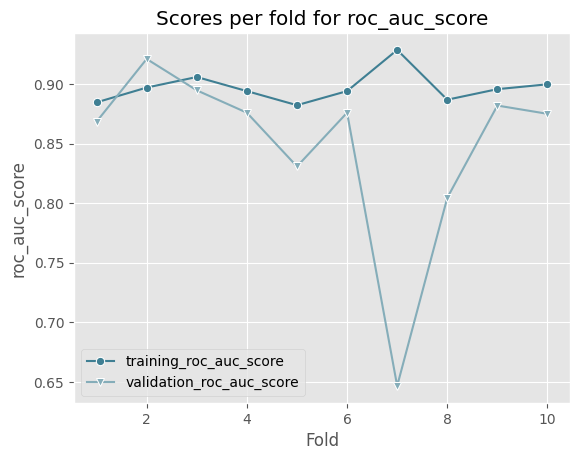

2026/06/28 13:45:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [ ]:
rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", rf)
])

with mlflow.start_run(run_name="RandomForestClassifier Scaled Model: Metric = roc_auc_score"):
    rf_model, rf_final_test_roc_auc_score, rf_roc_auc_scores_df, rf_y_pred_test = train_and_evaluate_model(rf_pipeline, X_train, y_train, X_test, y_test, roc_auc_score, skf, plot=True)

    # Log model metrics
    mlflow.log_metric("RandomForestClassifier_final_test_roc_auc_score", rf_final_test_roc_auc_score)
    mlflow.log_params(best_hyperparams_rf)

    # Log the model
    model_path = "RandomForestClassifier_scaled_model_roc_auc_score"
    mlflow.sklearn.log_model(rf_pipeline, model_path)

    # Register the model in the Model Registry
    mlflow.register_model(model_uri=f"runs:/{mlflow.active_run().info.run_id}/{model_path}", name="RandomForestClassifier_scaled_model_roc_auc")

    # Log artifacts
    rf_roc_auc_scores_df.to_csv("mlflow_model_csv_data/rf_scaled_roc_auc_scores.csv", index=False)
    mlflow.log_artifact("mlflow_model_csv_data/rf_scaled_roc_auc_scores.csv")

In [ ]:
plot_roc_curve(y_test,rf_y_pred_test)

In [ ]:

feature_importances = rf_model.named_steps["classifier"].feature_importances_

columns = X_train.columns
plt.figure(figsize=(16, 10))
sns.barplot(x=columns, y=feature_importances)
plt.xlabel("Features")
plt.ylabel("Coefficient Values")
plt.title("Coefficients of Features")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Model Selection Outcome

Detecting individuals at risk of heart disease is of critical importance. In this process, ensuring that a person with heart disease is not mistakenly classified as healthy is vital. For this reason, the recall metric was chosen as the primary evaluation measure.
Additionally, a secondary evaluation was performed using roc_auc_score to measure how well the model separates the classes.

As a result, model selection was based on two performance metrics: recall and roc_auc_score.

The recall and roc_auc_score values achieved by the Logistic Regression and Random Forest models are shown below.

Both models demonstrated similar performance. However, the Random Forest Classifier was chosen as the final model due to its built-in feature selection capability


Comparison of Model Performance Metrics

In [ ]:
scores_data = {
    "Model": ["Logistic Regression"] * 2 + ["Random Forest"] * 2,
    "Metric": ["Precision Score", "Roc AUC Score"] * 2,
    "Score": [lr_final_test_recall_score, lr_final_test_roc_auc_score, rf_final_test_recall_score, rf_final_test_roc_auc_score]
}
scores_df = pd.DataFrame(scores_data)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x="Model", y="Score", hue="Metric", data=scores_df)
for container in ax.containers:
    ax.bar_label(container, fmt='%0.2f', label_type="edge")
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.legend(loc="upper center")
plt.show()


## Comparison of Features Selected by the Models

The chart below visualizes the feature importance scores of both Logistic Regression and Random Forest Classifier models, scaled to the same range for direct comparison.

### Key Observations:

1. Scaling: Feature importance values from both models are normalized to allow a fair comparison on a single chart.
2. Negativity in Logistic Regression: Logistic Regression assigns both positive and negative weights to features, reflecting their influence direction. On the other hand, Random Forest Classifier does not assign negative importance to any feature, as its approach differs.
3. Similarity in Feature Selection: Despite differences in their mechanisms, both models tend to prioritize similar features. This consistency reinforces the reliability of the selected features.
The comparison demonstrates that both models align in identifying the most relevant features for predicting heart disease, enhancing confidence in the feature engineering and selection process.

In [ ]:
feature_dict = {"Features":X_train.columns,"Logistic Regression Features": coef_values, "RandomforestClassifier Features": feature_importances}
models_features_df = pd.DataFrame(feature_dict)
models_features_df.set_index("Features",inplace=True)

scaler = MinMaxScaler()
models_features_df_scaled =scaler.fit_transform(models_features_df)
df_scaled_features = pd.DataFrame(models_features_df_scaled, columns=models_features_df.columns, index=models_features_df.index)

In [ ]:
plt.figure(figsize=(18, 8))
sns.lineplot(df_scaled_features, markers="o")
plt.title("Graph Comparing Feature Weights Assigned by the Models")
plt.xlabel("Features")
plt.ylabel("Weights")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


## MODEL PIPELINE CREATION AND DEPLOYMENT:
* Pipeline Construction:
All preprocessing and modeling steps applied to the dataset have been encapsulated in an sklearn pipeline. This is essential because real-world data often comes in raw form, and a pipeline ensures a consistent and repeatable process for handling such data. Each step in the pipeline inherits from the BaseEstimator class of sklearn, creating a modular and maintainable structure.

* Model Saving:
The finalized model, including all preprocessing steps, has been saved using mlflow. This allows for easy tracking, versioning, and deployment of the model.

* Frontend and Backend Integration:
The project has been transformed into a deployable application using the Gradio and FastAPI libraries.

* Gradio provides an intuitive frontend for user interaction, making it easy to visualize and test the model.
FastAPI handles backend processes, enabling efficient and scalable deployment of the model.

In [ ]:
class OutlierReplacer(BaseEstimator, TransformerMixin):
    def __init__(self, variables):
        self.variables = variables

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        for variable in self.variables:
            low_limit, up_limit = self.outlier_thresholds(X, variable)
            X.loc[(X[variable] > up_limit), variable] = up_limit
            if X[variable].min() > 0:
                X.loc[(X[variable] < low_limit), variable] = low_limit
        return X

    def outlier_thresholds(self, X, variable, q1_thr=0.25, q3_thr=0.75):
        quartile1 = X[variable].quantile(q1_thr)
        quartile3 = X[variable].quantile(q3_thr)
        interquantile_range = quartile3 - quartile1
        up_limit = quartile3 + 1.5 * interquantile_range
        low_limit = quartile1 - 1.5 * interquantile_range
        return low_limit, up_limit


class FeatureGenerator(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        X = X.copy()

        age_bins = [-np.inf, 18, 40, 60, np.inf]
        age_labels = [0, 1, 2, 3]
        X['age_category'] = pd.cut(X['age'], bins=age_bins, labels=age_labels)

        mhr_bins = [-np.inf, 100, 200, 300, np.inf]
        mhr_labels = [0, 1, 2, 3]
        X['serum_cholesterol_category'] = pd.cut(X['serum_cholesterol'], bins=mhr_bins, labels=mhr_labels)

        X['bp_cholesterol_ratio'] = X['resting_blood_pressure'] / X['serum_cholesterol']

        return X


class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.85):
        self.threshold = threshold

    def fit(self, X, y=None):
        if isinstance(X, np.ndarray):
            X = pd.DataFrame(X)
        elif not isinstance(X, pd.DataFrame):
            raise ValueError("X, must be Pandas DataFrame.")

        corr_matrix = X.corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        self.to_drop = [column for column in upper.columns if any(upper[column] > self.threshold)]
        return self

    def transform(self, X, y=None):
        if isinstance(X, np.ndarray):
            X = pd.DataFrame(X)
        elif not isinstance(X, pd.DataFrame):
            raise ValueError("X, must be Pandas DataFrame.")

        return X.drop(columns=self.to_drop, errors='ignore')


one_hot_cat_features = ["chest_pain_type", "resting_ecg_results", "thal", "slope_peak_exercise_st_segment"]
ordinal_age_cat_features = ["age_category"]
ordinal_serum_cat_features = ["serum_cholesterol_category"]
numerical_features = ["age", "resting_blood_pressure", "serum_cholesterol", "maximum_heart_rate_achieved", "st_depression_induced_by_exercise", "number_major_vessels", "bp_cholesterol_ratio"]
outlier_features = ["age", "resting_blood_pressure", "serum_cholesterol", "maximum_heart_rate_achieved", "st_depression_induced_by_exercise"]

one_hot_cat_transformer = OneHotEncoder()
ordinal_cat_trainsformer = OrdinalEncoder(categories=[[0, 1, 2, 3]])
numerical_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat_ohe', one_hot_cat_transformer, one_hot_cat_features),
        ('age_cat_ord', ordinal_cat_trainsformer, ordinal_age_cat_features),
        ('serum_cat_ord', ordinal_cat_trainsformer, ordinal_serum_cat_features),
    ],
    remainder='passthrough'
)

pipeline = Pipeline(steps=[
    ('outlier_replacer', OutlierReplacer(variables=outlier_features)),
    ('feature_generator', FeatureGenerator()),
    ('preprocessor', preprocessor),
    ('correlation_filter', CorrelationFilter(threshold=0.82)),
    ('classifier', RandomForestClassifier(**best_hyperparams_rf, random_state=22))
])


def train_and_log_model(X, y):
    with mlflow.start_run(run_name="RandomForestClassifier Production Model: Metric = recall"):
        pipeline.fit(X, y)
        model_path = "final_rf_model"
        mlflow.log_params(best_hyperparams_rf)
        mlflow.sklearn.log_model(pipeline, model_path)
        mlflow.register_model(model_uri=f"runs:/{mlflow.active_run().info.run_id}/{model_path}", name=model_path)

In [ ]:
pipeline[-1]

In [ ]:
df = pd.read_csv("raw_heart_disease_data.csv")
df.head()

In [ ]:
df.dropna(inplace=True)

In [ ]:
target = "presence_of_heart_disease"
X = df.drop(target, axis=1)
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.12,stratify=y, random_state=42)

Verification of Applied Changes

* It has been verified that outlier analysis has been conducted and new features have been added to the dataset.

In [ ]:
train_and_log_model(X_train, y_train)

In [ ]:
low_limit, up_limit = outlier_thresholds(X_train, "resting_blood_pressure")
show_outliers(X_train,"resting_blood_pressure", low_limit, up_limit)

In [ ]:
X_transformed = pipeline.named_steps['outlier_replacer'].transform(X_train)
X_transformed = pipeline.named_steps['feature_generator'].transform(X_transformed)
# X_transformed = pipeline.named_steps['preprocessor'].transform(X_transformed)
# X_transformed = pipeline.named_steps['correlation_filter'].transform(X_transformed)
low_limit, up_limit = outlier_thresholds(X_transformed, "resting_blood_pressure")
show_outliers(X_transformed,"resting_blood_pressure", low_limit, up_limit)

In [ ]:
model_path = "models:/final_rf_model/1"
model = mlflow.sklearn.load_model(model_path)

In [ ]:
y_pred_final = model.predict(X_test)
final_recall_core = recall_score(y_test, y_pred_final)
print(f"Test Recall: {final_recall_core:.4f}")

In [ ]:
sample_data1 = X_test.iloc[0:1]
sample_data2 = X_test.iloc[1:2]

In [ ]:
predicted_class = model.predict(sample_data1)
predicted_class


## CONCLUSION AND RECOMMENDATIONS
* **Incorporate Expert Knowledge:** By conducting a medical literature review and consulting with expert doctors, additional relevant features can be identified and added to the model.
* **Increase Data Volume:** To improve model predictions, the amount of data should be increased. Larger datasets can lead to better generalization and higher accuracy.
* **Perform Advanced Data Analysis:** After adding new features, tools like Power BI can be used to conduct more detailed data analysis, uncovering hidden relationships and potential new causes for heart conditions.
* **Enhance Code Management:** The pipeline structure can be modularized and saved into separate Python files. Tools like DVC and Hydra can be employed for better manageability, and CI/CD workflows can be automated with GitHub Actions or Jenkins.
* **Leverage Cloud Platforms:** The model can be deployed on cloud platforms. For instance, AWS services like VPC for network setup, EC2, S3, Lambda, API Gateway, DynamoDB, and SageMaker can be integrated for a fully automated cloud deployment.
* **Store Predictions:** Prediction outputs can be saved to a database for further analysis and tracking.
* **Monitor Model Performance:** Once the model is in production, its performance should be continuously monitored to detect issues like data drift, enabling timely updates and maintenance.
* **Professional Deployment:** For a polished product, a professional tech stack can be adopted. React or Vue.js can be used for the frontend, while Node.js or .NET can serve as backend frameworks for building a robust and user-friendly application.

In [ ]:
!zip -r mlruns.zip mlruns

In [ ]:
import joblib
import os

# Create models folder
os.makedirs("models", exist_ok=True)

# Save complete pipeline
joblib.dump(
    pipeline,
    "models/final_rf_model.pkl"
)

print("Pipeline saved successfully!")

In [ ]:
!zip -r models.zip models

In [ ]:
import sklearn
print(sklearn.__version__)

In [ ]:
X_train.dtypes